In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


**WHAT NEXT OR WHT LEFT?????**
1. check the format of citizenship_no and solve the pooblem
2. Check district-provience combination (need to ask techer because we can solve this by mapping only by assuming district are correct)
3. Then after solving these problems check for row-level near_duplicasy and drop those columns



In [ ]:
df1 = pd.read_csv("applicant_profiles.csv")
df1.columns

Index(['applicant_id', 'full_name_en', 'father_name_en', 'grandfather_name_en',
       'citizenship_number', 'citizenship_date_bs', 'citizenship_office',
       'dob_ad', 'dob_bs', 'gender', 'marital_status', 'province_en',
       'district_en', 'municipality_en', 'ward_no', 'phone_primary',
       'occupation_en', 'occupation_np', 'education_level', 'household_size',
       'land_area_ropani', 'has_esewa_account', 'has_khalti_account',
       'esewa_account_id', 'khalti_account_id', 'primary_bank',
       'remittance_receiving', 'cooperative_member', 'cooperative_id',
       'kyc_tier', 'rural_urban', 'profile_created_date', '_noise_geo_wrong',
       '_noise_ward_issue', '_noise_dob_bad', '_noise_name_format',
       '_noise_cit_bad', '_noise_phone_bad', '_noise_edu_missing',
       '_noise_duplicate'],
      dtype='object')

In [ ]:
df1.shape

(100000, 40)

In [ ]:
# nromalize naming format

name_cols = [
    "full_name_en",
    "father_name_en",
    "grandfather_name_en"
]

for col in name_cols:
    df1[col] = (
        df1[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)   # remove extra spaces
        .str.title()                            # Proper Case
    )

In [ ]:
columns_to_drop = [
    'full_name_en',
    'father_name_en',
    'grandfather_name_en',
    'citizenship_number',
    'citizenship_date_bs',
    'citizenship_office',
    'municipality_en',
    'ward_no',
    'phone_primary',
    'occupation_np'
]
df1.drop(columns=columns_to_drop, inplace=True)
df1.head()

,applicant_id,dob_ad,dob_bs,gender,marital_status,province_en,district_en,occupation_en,education_level,household_size,...,rural_urban,profile_created_date,_noise_geo_wrong,_noise_ward_issue,_noise_dob_bad,_noise_name_format,_noise_cit_bad,_noise_phone_bad,_noise_edu_missing,_noise_duplicate
0,AP-000001,1949-10-22,2006-10-22,male,Married,Lumbini,Rupandehi,Small Trader,SLC,7,...,rural,2081-01-10,False,False,False,False,False,False,False,False
1,AP-000002,1942-03-04,1999-03-04,male,Married,Koshi,Sunsari,Artisan,Bachelors,5,...,rural,2081-01-10,False,False,False,False,False,False,False,False
2,AP-000003,1958-04-21,2015-04-21,male,Married,Lumbini,Kapilvastu,Business Owner,Intermediate,7,...,urban,2081-01-10,False,False,False,False,False,False,False,False
3,AP-000004,1966-07-02,2023-07-02,female,Widowed,Lumbini,Rupandehi,Daily Wage Worker,SLC,8,...,semi_urban,2081-01-10,False,False,False,True,True,False,False,False
4,AP-000005,1987-10-11,2044-10-11,male,Married,Bagmati,Lalitpur,Farmer,Bachelors,3,...,semi_urban,2081-01-10,False,False,False,False,False,False,False,False


In [ ]:
df1['dob_ad'] = pd.to_datetime(df1['dob_ad'], errors='coerce')


present = pd.to_datetime('2024-06-30')

# Create an 'age' column.
df1['age'] = (present - df1['dob_ad']).dt.days / 365.25

df1['age']



,age
0,74.688569
1,82.324435
2,66.193018
3,57.995893
4,36.720055
...,...
99995,42.305270
99996,106.247775
99997,72.462697
99998,70.395619


In [ ]:
'''
# Define the valid date range for 'dob_ad'
min_dob_ad_date = pd.to_datetime('1924-01-01')
max_dob_ad_date = pd.to_datetime('2024-12-31')

# Identify rows where 'dob_ad' is outside the specified range
rows_to_drop_mask = (df1['dob_ad'] < min_dob_ad_date) | (df1['dob_ad'].isnull()) | (df1['dob_ad'] > max_dob_ad_date)

# Calculate the number of rows to be dropped
num_dropped_rows = rows_to_drop_mask.sum()

# Drop the identified rows from the DataFrame
df1 = df1[~rows_to_drop_mask].copy()

print(f"Number of rows with 'dob_ad' outside the 1924-2024 range or null that were dropped: {num_dropped_rows}")
print("\nFirst 5 rows of the DataFrame after dropping:")
print(df1[['dob_ad', 'age']].head())
'''

'\n# Define the valid date range for \'dob_ad\'\nmin_dob_ad_date = pd.to_datetime(\'1924-01-01\')\nmax_dob_ad_date = pd.to_datetime(\'2024-12-31\')\n\n# Identify rows where \'dob_ad\' is outside the specified range\nrows_to_drop_mask = (df1[\'dob_ad\'] < min_dob_ad_date) | (df1[\'dob_ad\'].isnull()) | (df1[\'dob_ad\'] > max_dob_ad_date)\n\n# Calculate the number of rows to be dropped\nnum_dropped_rows = rows_to_drop_mask.sum()\n\n# Drop the identified rows from the DataFrame\ndf1 = df1[~rows_to_drop_mask].copy()\n\nprint(f"Number of rows with \'dob_ad\' outside the 1924-2024 range or null that were dropped: {num_dropped_rows}")\nprint("\nFirst 5 rows of the DataFrame after dropping:")\nprint(df1[[\'dob_ad\', \'age\']].head())\n'

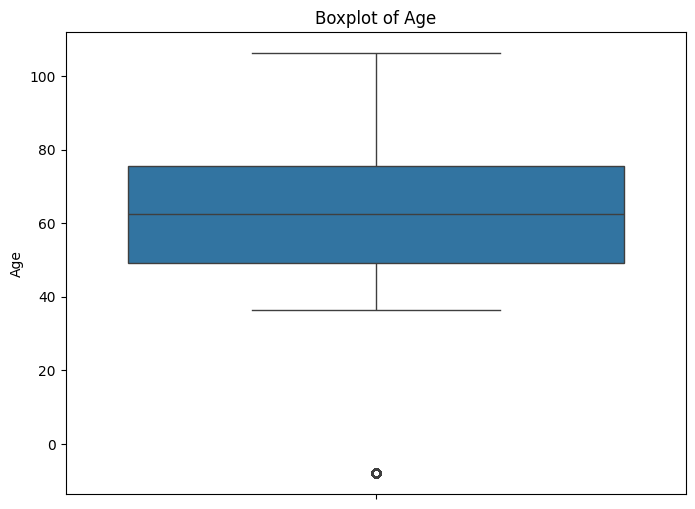

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(y=df1['age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

In [ ]:
df1.drop(columns=['dob_ad', 'dob_bs'], inplace=True)
noise_dob_remaining = df1[df1['_noise_dob_bad'] == True].shape[0]
print(f"Number of rows with '_noise_dob_bad' still True after dropping 'dob_ad' and 'dob_bs': {noise_dob_remaining}")

Number of rows with '_noise_dob_bad' still True after dropping 'dob_ad' and 'dob_bs': 1317


In [ ]:
df1.shape

(100000, 29)

In [ ]:
df1.head()

,applicant_id,gender,marital_status,province_en,district_en,occupation_en,education_level,household_size,land_area_ropani,has_esewa_account,...,profile_created_date,_noise_geo_wrong,_noise_ward_issue,_noise_dob_bad,_noise_name_format,_noise_cit_bad,_noise_phone_bad,_noise_edu_missing,_noise_duplicate,age
0,AP-000001,male,Married,Lumbini,Rupandehi,Small Trader,SLC,7,6,False,...,2081-01-10,False,False,False,False,False,False,False,False,74.688569
1,AP-000002,male,Married,Koshi,Sunsari,Artisan,Bachelors,5,7,True,...,2081-01-10,False,False,False,False,False,False,False,False,82.324435
2,AP-000003,male,Married,Lumbini,Kapilvastu,Business Owner,Intermediate,7,2,True,...,2081-01-10,False,False,False,False,False,False,False,False,66.193018
3,AP-000004,female,Widowed,Lumbini,Rupandehi,Daily Wage Worker,SLC,8,17,False,...,2081-01-10,False,False,False,True,True,False,False,False,57.995893
4,AP-000005,male,Married,Bagmati,Lalitpur,Farmer,Bachelors,3,6,True,...,2081-01-10,False,False,False,False,False,False,False,False,36.720055


In [ ]:
''' to drop: province_en 	district_en, _noise_geo_wrong 	_noise_ward_issue 	_noise_dob_bad 	_noise_name_format 	_noise_cit_bad 	_noise_phone_bad 	_noise_edu_missing,
education_level (if null make thatbseerate category)
profile_created_date   =calculate acc age
dlt duplicate rows
then check if any riw still has  _noise_duplicate  true '''


' to drop: province_en \tdistrict_en, _noise_geo_wrong \t_noise_ward_issue \t_noise_dob_bad \t_noise_name_format \t_noise_cit_bad \t_noise_phone_bad \t_noise_edu_missing,\neducation_level (if null make thatbseerate category)\nprofile_created_date   =calculate acc age\ndlt duplicate rows\nthen check if any riw still has  _noise_duplicate  true '

In [ ]:
# 1. Drop specified columns
columns_to_drop_now = [
    'province_en',
    'district_en',
    '_noise_geo_wrong',
    '_noise_ward_issue',
    '_noise_dob_bad',
    '_noise_name_format',
    '_noise_cit_bad',
    '_noise_phone_bad',
    '_noise_edu_missing'
]

# Ensure columns exist before attempting to drop and use errors='ignore'
df1.drop(columns=columns_to_drop_now, inplace=True, errors='ignore')
existing_columns_dropped = [col for col in columns_to_drop_now if col not in df1.columns]
print(f"Dropped columns (or they were already absent): {existing_columns_dropped}")

# 2. Handle 'education_level' nulls
df1['education_level'] = df1['education_level'].fillna('Unknown')
print(f"\nNulls in 'education_level' after imputation: {df1['education_level'].isnull().sum()}")


Dropped columns (or they were already absent): ['province_en', 'district_en', '_noise_geo_wrong', '_noise_ward_issue', '_noise_dob_bad', '_noise_name_format', '_noise_cit_bad', '_noise_phone_bad', '_noise_edu_missing']

Nulls in 'education_level' after imputation: 0


In [ ]:
# 3. Calculate 'account_age' from 'profile_created_date'
if 'profile_created_date' in df1.columns:
    initial_profile_created_date_nulls = df1['profile_created_date'].isnull().sum()
    print(f"\nNumber of nulls in 'profile_created_date' before processing: {initial_profile_created_date_nulls}")

    df1['profile_created_date'] = pd.to_datetime(df1['profile_created_date'], errors='coerce')

    post_coerce_profile_created_date_nulls = df1['profile_created_date'].isna().sum()
    print(f"Number of NaT values (unparseable dates) in 'profile_created_date' after conversion: {post_coerce_profile_created_date_nulls}")

    # Use the same 'present' date as used for 'age' calculation
    present = pd.to_datetime('2024-06-30')

    # Calculate account_age, ensuring it's not negative. If profile_created_date is in the future or NaN, set account_age to NaN.
    future_or_nat_dates = (df1['profile_created_date'] > present) | (df1['profile_created_date'].isna())
    df1.loc[~future_or_nat_dates, 'account_age'] = (present - df1['profile_created_date']).dt.days / 365.25
    df1.loc[future_or_nat_dates, 'account_age'] = np.nan

    negative_account_age_count = (df1['account_age'] < 0).sum()
    nan_account_age_count = df1['account_age'].isna().sum()

    print(f"Number of negative 'account_age' values after calculation (should be 0): {negative_account_age_count}")
    print(f"Number of NaN 'account_age' values after calculation: {nan_account_age_count}")

    # "if all fine drop the profile created date"
    # Interpreting 'all fine' as no negative ages (which are already converted to NaN by the logic)
    # and at least some account ages were successfully calculated (i.e., not all are NaN).
    if negative_account_age_count == 0 and nan_account_age_count < len(df1):
        df1.drop(columns=['profile_created_date'], inplace=True)
        print("\n'account_age' calculated successfully for some rows, and 'profile_created_date' dropped.")
    else:
        print("\nWarning: 'account_age' calculation resulted in issues (e.g., all NaN). 'profile_created_date' has not been dropped.")

elif 'account_age' not in df1.columns:
    df1['account_age'] = np.nan
    print("\n'profile_created_date' column not found. 'account_age' cannot be calculated and has been initialized to NaN.")
else:
    print("\n'profile_created_date' column not found. 'account_age' was already present (possibly from a prior attempt to calculate it).")



Number of nulls in 'profile_created_date' before processing: 0
Number of NaT values (unparseable dates) in 'profile_created_date' after conversion: 0
Number of negative 'account_age' values after calculation (should be 0): 0
Number of NaN 'account_age' values after calculation: 100000



In [ ]:
# Install the nepali_datetime library for BS to AD conversion
%pip install nepali_datetime

import nepali_datetime

bs_date = nepali_datetime.date(2080, 3, 15)
ad_date = bs_date.to_datetime_date()

print(ad_date)

2023-06-30


In [ ]:
print(df1['profile_created_date'].dtype)
print(df1['profile_created_date'].head())

datetime64[ns]
0   2081-01-10
1   2081-01-10
2   2081-01-10
3   2081-01-10
4   2081-01-10
Name: profile_created_date, dtype: datetime64[ns]


Problem: Dataset description says: Date the applicant profile was created in the system (AD format).

BUT THE COLUMN HAS DATES IN BS.

In [ ]:
import pandas as pd
import nepali_datetime

def bs_to_ad(date):
    if pd.isna(date):
        return pd.NaT

    try:
        bs_date = nepali_datetime.date(date.year, date.month, date.day)
        return pd.Timestamp(bs_date.to_datetime_date())
    except Exception:
        return pd.NaT

df1['profile_created_date_ad'] = df1['profile_created_date'].apply(bs_to_ad)

In [ ]:
today = pd.Timestamp.today().normalize()

df1['acc_age_days'] = (
    today - df1['profile_created_date_ad']
).dt.days
df1['acc_age_months'] = df1['acc_age_days'] / 30

In [ ]:
df1['acc_age_years'] = df1['acc_age_days'] / 365.25
display(df1['acc_age_years'].head())

,acc_age_years
0,2.195756
1,2.195756
2,2.195756
3,2.195756
4,2.195756


As observed in the boxplot for account age, the histogram below also shows a single bar. This is because the `profile_created_date` column uniformly contained the value '2081-01-10' (BS), which converts to '2024-04-22' (AD). As a result, the calculated account age for all applicants is constant.

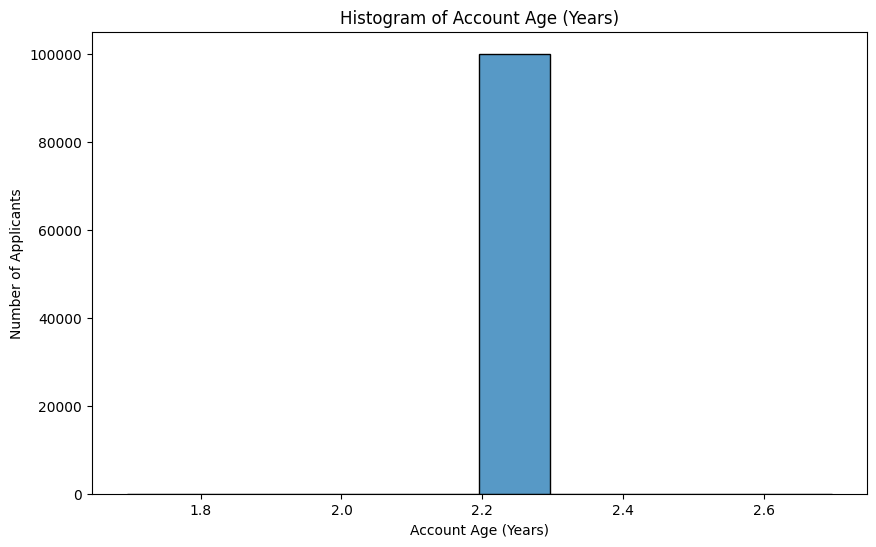

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df1['acc_age_years'], bins=10, kde=False)
plt.title('Histogram of Account Age (Years)')
plt.xlabel('Account Age (Years)')
plt.ylabel('Number of Applicants')
plt.show()

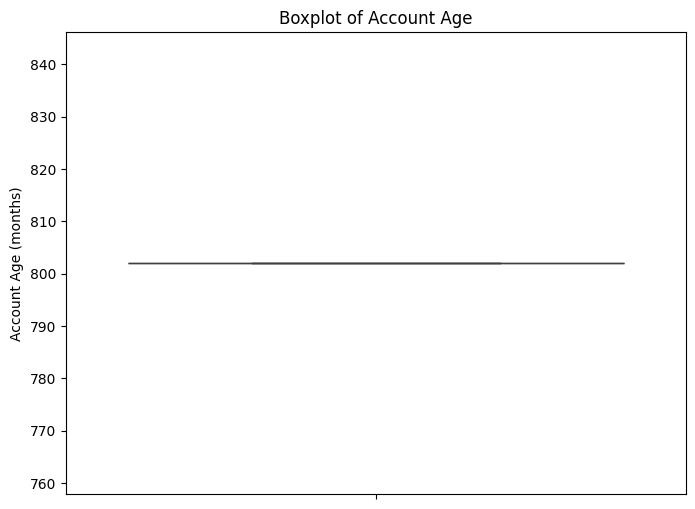

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(y=df1['acc_age_days'])
plt.title('Boxplot of Account Age')
plt.ylabel('Account Age (months)')
plt.show()

In [ ]:
# THERE SHOULD BE SINGLE PROFILE CREATED DATE FOR ALL ROWS SO CHECKING IT AS A CATEGORICAK COLUMN

unique_profile_dates = df1['profile_created_date'].unique()
print("Unique profile creation dates (AD):")
for date in unique_profile_dates:
    print(date.strftime('%Y-%m-%d') if pd.notna(date) else 'NaT')

Unique profile creation dates (AD):
2081-01-10


In [ ]:
# Columns to drop due to uniform values
columns_to_drop_final = [
    'profile_created_date',
    'profile_created_date_ad',
    'acc_age_days',
    'acc_age_months',
    'acc_age_years'
]

# Drop columns if they exist in the DataFrame
for col in columns_to_drop_final:
    if col in df1.columns:
        df1.drop(columns=[col], inplace=True)
        print(f"Dropped column: {col}")
    else:
        print(f"Column not found, skipped: {col}")

# Display the updated columns to confirm the drops
print("\nRemaining columns in df1:")
print(df1.columns.tolist())

Dropped column: profile_created_date
Dropped column: profile_created_date_ad
Dropped column: acc_age_days
Dropped column: acc_age_months
Dropped column: acc_age_years

Remaining columns in df1:
['applicant_id', 'gender', 'marital_status', 'occupation_en', 'education_level', 'household_size', 'land_area_ropani', 'has_esewa_account', 'has_khalti_account', 'esewa_account_id', 'khalti_account_id', 'primary_bank', 'remittance_receiving', 'cooperative_member', 'cooperative_id', 'kyc_tier', 'rural_urban', '_noise_duplicate', 'age', 'account_age']


In [ ]:
# SOLVING_noise_duplicate problem

print(f"Current number of rows in df1: {len(df1)}")

# 1. Check for complete duplicate rows
initial_rows_before_full_duplicate_check = len(df1)
duplicated_rows_count = df1.duplicated().sum()
print(f"\nNumber of completely duplicated rows: {duplicated_rows_count}")

# 2. Check for duplicate applicant_id
duplicated_applicant_id_count = df1['applicant_id'].duplicated().sum()
print(f"Number of rows with duplicated 'applicant_id': {duplicated_applicant_id_count}")

# 2. Check for duplicate  'esewa_account_id'
duplicated_esewa_account_id_count = df1['esewa_account_id'].duplicated().sum()
print(f"Number of rows with duplicated 'esewa_account_id': {duplicated_esewa_account_id_count}")



# 2. Check for duplicate  'khalti_account_id'
duplicated_khalti_account_id_count = df1['khalti_account_id'].duplicated().sum()
print(f"Number of rows with duplicated 'khalti_account_id': {duplicated_khalti_account_id_count}")

# 3. Check the status of the _noise_duplicate column
noise_duplicates_true_count = df1['_noise_duplicate'].sum()
print(f"Number of rows where '_noise_duplicate' is True: {noise_duplicates_true_count}")

Current number of rows in df1: 100000

Number of completely duplicated rows: 0
Number of rows with duplicated 'applicant_id': 0
Number of rows with duplicated 'esewa_account_id': 42085
Number of rows with duplicated 'khalti_account_id': 67669
Number of rows where '_noise_duplicate' is True: 1473


In [ ]:
df1[['esewa_account_id', 'khalti_account_id']].sample(n=10, random_state=42)


,esewa_account_id,khalti_account_id
75721,NaN,NaN
80184,ESW-AP-080185,KHL-AP-080185
19864,NaN,KHL-AP-019865
76699,ESW-AP-076700,NaN
92991,ESW-AP-092992,NaN
76434,NaN,NaN
84004,ESW-AP-084005,NaN
80917,ESW-AP-080918,KHL-AP-080918
60767,NaN,NaN
50074,NaN,KHL-AP-050075


In [ ]:
# Check for duplicate 'esewa_account_id' when 'has_esewa_account' is True
duplicated_esewa_account_id_count = df1[df1['has_esewa_account'] == True]['esewa_account_id'].duplicated().sum()
print(f"Number of rows with duplicated 'esewa_account_id' (where has_esewa_account is True): {duplicated_esewa_account_id_count}")

# Check for duplicate 'khalti_account_id' when 'has_khalti_account' is True
duplicated_khalti_account_id_count = df1[df1['has_khalti_account'] == True]['khalti_account_id'].duplicated().sum()
print(f"Number of rows with duplicated 'khalti_account_id' (where has_khalti_account is True): {duplicated_khalti_account_id_count}")

Number of rows with duplicated 'esewa_account_id' (where has_esewa_account is True): 0
Number of rows with duplicated 'khalti_account_id' (where has_khalti_account is True): 0


In [ ]:
# Define a subset of columns to check for 'near duplicates'
# These columns are chosen because they are descriptive and less likely to vary for the same individual
near_duplicate_check_cols = [
    'gender',
    'marital_status',
    'occupation_en',
    'education_level',
    'age'

]

# Check for duplicates based on this subset of columns
near_duplicates = df1[df1.duplicated(subset=near_duplicate_check_cols, keep=False)].sort_values(by=near_duplicate_check_cols)

print(f"Number of rows identified as potential 'near duplicates' based on the defined subset of columns: {len(near_duplicates)}")

if not near_duplicates.empty:
    print("\nFirst 10 potential 'near duplicates' (sorted by the check columns):")
    display(near_duplicates.head(10))
else:
    print("\nNo potential 'near duplicates' found based on the defined subset of columns.")

# Note: Deciding whether to drop these or how to handle them requires domain knowledge
# and understanding of what constitutes a true duplicate in your context.

Number of rows identified as potential 'near duplicates' based on the defined subset of columns: 5392

First 10 potential 'near duplicates' (sorted by the check columns):


,applicant_id,gender,marital_status,occupation_en,education_level,household_size,land_area_ropani,has_esewa_account,has_khalti_account,esewa_account_id,khalti_account_id,primary_bank,remittance_receiving,cooperative_member,cooperative_id,kyc_tier,rural_urban,_noise_duplicate,age,account_age
59111,AP-059112,female,Divorced,Small Trader,SLC,7,13,True,False,ESW-AP-059112,NaN,NIC Asia Bank,False,True,COOP-KAN-0197,mid,urban,False,45.127995,NaN
67025,AP-067026,female,Divorced,Small Trader,SLC,8,18,True,False,ESW-AP-067026,NaN,Himalayan Bank,True,False,NaN,mid,semi_urban,False,45.127995,NaN
31233,AP-031234,female,Married,Artisan,Bachelors,7,0,False,False,NaN,NaN,Nabil Bank,False,False,NaN,full,semi_urban,False,-7.958932,NaN
48190,AP-048191,female,Married,Artisan,Bachelors,4,6,True,False,ESW-AP-048191,NaN,Citizens Bank,True,True,COOP-CHI-0283,basic,rural,False,-7.958932,NaN
50521,AP-050522,female,Married,Artisan,Bachelors,7,11,False,False,NaN,NaN,Everest Bank,False,False,NaN,basic,semi_urban,False,-7.958932,NaN
17915,AP-017916,female,Married,Artisan,Bachelors,2,2,False,False,NaN,NaN,NIC Asia Bank,False,True,COOP-RUP-0044,basic,rural,False,59.263518,NaN
58407,AP-058408,female,Married,Artisan,Bachelors,3,0,False,False,NaN,NaN,Prime Bank,False,True,COOP-BAN-0067,mid,semi_urban,False,59.263518,NaN
11239,AP-011240,female,Married,Artisan,Bachelors,4,0,False,False,NaN,NaN,Nabil Bank,False,False,NaN,mid,urban,False,68.492813,NaN
25127,AP-025128,female,Married,Artisan,Bachelors,6,0,False,False,NaN,NaN,Nepal Investment Bank,False,True,COOP-SUN-0246,basic,urban,False,68.492813,NaN
65499,AP-065500,female,Married,Artisan,Bachelors,2,1,True,False,ESW-AP-065500,NaN,Citizens Bank,True,False,NaN,mid,urban,False,74.431211,NaN


In [ ]:
df1.columns
df1.shape

(100000, 20)

**NOW STARTING WITH LOANAPPLICATIONS.CSV**

In [ ]:
# Load the dataset
df2 = pd.read_csv('loan_applications.csv')
df2.sample(5)

,application_id,applicant_id,application_date_ad,application_date_bs,loan_purpose,requested_amount_nrs,requested_tenure_months,province_en,district_en,municipality_en,...,processing_time_seconds,data_split,_noise_amount_string,_noise_negative_amount,_noise_tenure_missing,_noise_decision_missing,_noise_interest_oor,_noise_duplicate_app,decision_reason,composite_creditworthiness_score
59406,LA-2081-059406,AP-059407,2023-02-11,2080-02-11,small_trade,50000,6,Koshi,Morang,Biratnagar Metropolitan City,...,86,train,False,False,False,False,False,False,ADEQUATE_PROFILE,0.7554
21354,LA-2081-021354,AP-021355,2024-03-18,2081-03-18,vehicle_purchase,200000,24,Lumbini,Rupandehi,Butwal Sub-Metropolitan City,...,199,train,False,False,False,False,False,False,MANUAL_REVIEW_REQUIRED,0.4520
88139,LA-2081-088139,AP-088140,2023-02-03,2080-02-03,agricultural_input,250000,18,Madhesh,Rautahat,Chandrapur Municipality,...,36,val,False,False,False,False,False,False,MANUAL_REVIEW_REQUIRED,0.4396
87117,LA-2081-087117,AP-087118,2023-06-11,2080-06-11,agricultural_input,100000,12,Bagmati,Sindhupalchok,Chautara Sangachokgadhi Municipality,...,146,val,False,False,False,False,False,False,MANUAL_REVIEW_REQUIRED,0.5760
50387,LA-2081-050387,AP-050388,2024-02-20,2081-02-20,microenterprise_startup,75000,12,Bagmati,Kathmandu,Kathmandu Metropolitan City,...,173,val,False,False,False,False,False,False,MANUAL_REVIEW_REQUIRED,0.4291


In [ ]:
df2.shape

(100000, 44)

In [ ]:
# Apply the cleaning steps to 'requested_amount_nrs' column
df2['requested_amount_nrs'] = (
    df2['requested_amount_nrs']
    .astype(str) # Convert to string first
    .str.replace('Rs. ', '', regex=False) # Strip "Rs. "
    .str.replace(',', '', regex=False) # Strip commas
    .astype(float) # Cast to float
    .abs() # Apply absolute value
)

print("Cleaned 'requested_amount_nrs' column head:")
print(df2['requested_amount_nrs'].head())
print("\nCleaned 'requested_amount_nrs' column info:")
df2['requested_amount_nrs'].info()

Cleaned 'requested_amount_nrs' column head:
0     50000.0
1    750000.0
2    250000.0
3    750000.0
4    150000.0
Name: requested_amount_nrs, dtype: float64

Cleaned 'requested_amount_nrs' column info:
<class 'pandas.core.series.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: requested_amount_nrs
Non-Null Count   Dtype  
--------------   -----  
100000 non-null  float64
dtypes: float64(1)
memory usage: 781.4 KB


In [ ]:
import numpy as np

# Calculate the median of 'requested_tenure_months'
median_tenure = df2['requested_tenure_months'].median()

# Impute NULL values with the calculated median
df2['requested_tenure_months'].fillna(median_tenure, inplace=True)

print(f"Median tenure used for imputation: {median_tenure}")
print("\nCleaned 'requested_tenure_months' column head:")
print(df2['requested_tenure_months'].head())
print("\nCleaned 'requested_tenure_months' column info:")
df2['requested_tenure_months'].info()

Median tenure used for imputation: 18.0

Cleaned 'requested_tenure_months' column head:
0     6
1     6
2    18
3     6
4    12
Name: requested_tenure_months, dtype: int64

Cleaned 'requested_tenure_months' column info:
<class 'pandas.core.series.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: requested_tenure_months
Non-Null Count   Dtype
--------------   -----
100000 non-null  int64
dtypes: int64(1)
memory usage: 781.4 KB


/tmp/ipykernel_15909/2494803486.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['requested_tenure_months'].fillna(median_tenure, inplace=True)


In [ ]:
# Create the binary 'has_cib_history' column
df2['has_cib_history'] = df2['credit_bureau_score'].notna()

print("Head of 'has_cib_history' column:")
print(df2['has_cib_history'].head())
print("\nValue counts of 'has_cib_history':")
print(df2['has_cib_history'].value_counts())
print("\nInfo of 'has_cib_history' column:")
df2['has_cib_history'].info()

Head of 'has_cib_history' column:
0    False
1    False
2    False
3    False
4    False
Name: has_cib_history, dtype: bool

Value counts of 'has_cib_history':
has_cib_history
False    72075
True     27925
Name: count, dtype: int64

Info of 'has_cib_history' column:
<class 'pandas.core.series.Series'>
RangeIndex: 100000 entries, 0 to 99999
Series name: has_cib_history
Non-Null Count   Dtype
--------------   -----
100000 non-null  bool 
dtypes: bool(1)
memory usage: 97.8 KB


In [ ]:
'''
# Remove rows where 'Doc_completeness_score' is null, as it indicates a failed documentation verification.
df2.dropna(subset=['doc_completeness_score'], inplace=True)

print("DataFrame shape after dropping nulls in 'doc_completeness_score':", df2.shape)
print("\n'doc_completeness_score' column info after cleaning:")
df2['doc_completeness_score'].info()
'''

'\n# Remove rows where \'Doc_completeness_score\' is null, as it indicates a failed documentation verification.\ndf2.dropna(subset=[\'doc_completeness_score\'], inplace=True)\n\nprint("DataFrame shape after dropping nulls in \'doc_completeness_score\':", df2.shape)\nprint("\n\'doc_completeness_score\' column info after cleaning:")\ndf2[\'doc_completeness_score\'].info()\n'

In [ ]:
''' print(f"DataFrame shape before dropping duplicates: {df2.shape}")

# Drop duplicates based on 'applicant_id', keeping the first occurrence
df2.drop_duplicates(subset=['applicant_id'], keep='first', inplace=True)

print(f"DataFrame shape after dropping duplicates: {df2.shape}")
display(df2.head())
'''

' print(f"DataFrame shape before dropping duplicates: {df2.shape}")\n\n# Drop duplicates based on \'applicant_id\', keeping the first occurrence\ndf2.drop_duplicates(subset=[\'applicant_id\'], keep=\'first\', inplace=True)\n\nprint(f"DataFrame shape after dropping duplicates: {df2.shape}")\ndisplay(df2.head())\n'

In [ ]:
# Count rows with interest_rate_pct > 15
violation_count = df2[df2['interest_rate_pct'] > 15].shape[0]
print(f"Number of rows with interest rate > 15%: {violation_count}")

# Drop rows where interest_rate_pct is greater than 15
print(f"Shape before filtering interest rate: {df2.shape}")
df2 = df2[df2['interest_rate_pct'] <= 15].copy()
print(f"Shape after filtering interest rate: {df2.shape}")

# Check the range of the interest_rate_pct column
print(f"New Interest Rate range: {df2['interest_rate_pct'].min()}% to {df2['interest_rate_pct'].max()}%")

Number of rows with interest rate > 15%: 0
Shape before filtering interest rate: (100000, 45)
Shape after filtering interest rate: (100000, 45)
New Interest Rate range: 0.0% to 13.5%


In [ ]:
df2['compliance_flags']

,compliance_flags
0,[]
1,"[""KYC_TIER_LIMIT"", ""LTI_EXCEEDED"", ""DOC_INCOMP..."
2,[]
3,"[""KYC_TIER_LIMIT"", ""LTI_EXCEEDED""]"
4,[]
...,...
99995,[]
99996,[]
99997,"[""KYC_TIER_LIMIT""]"
99998,[]


In [ ]:
import ast

# Reason: more flags means more chance of getting rejected so must affect the credit score
def count_flags(flag_str):
    try:
        # Convert string representation of list to actual list
        flags = ast.literal_eval(flag_str)
        return len(flags) if isinstance(flags, list) else 0
    except (ValueError, SyntaxError):
        return 0

# Create the no_of_flags column
df2['no_of_flags'] = df2['compliance_flags'].apply(count_flags)

print("Value counts for the new 'no_of_flags' column:")
print(df2['no_of_flags'].value_counts())

# Display sample with the new column
display(df2[['compliance_flags', 'no_of_flags']].head())

Value counts for the new 'no_of_flags' column:
no_of_flags
0    60138
1    31469
2     7102
3     1153
4      128
5       10
Name: count, dtype: int64


,compliance_flags,no_of_flags
0,[],0
1,"[""KYC_TIER_LIMIT"", ""LTI_EXCEEDED"", ""DOC_INCOMP...",3
2,[],0
3,"[""KYC_TIER_LIMIT"", ""LTI_EXCEEDED""]",2
4,[],0


In [ ]:
df2.shape

(100000, 46)

Columns to STRICTLY EXCLUDE (Data Leaks)
- score_band (Derived directly from target).
- final_decision (The outcome).
- approved_amount_nrs (The outcome).
- interest_rate_pct & interest_tier (The outcome).
- compliance_status & compliance_flags (Determined later in the pipeline).
- Any raw _noise_* columns.
- Interest_rate_pct and interest_tier  (done based on credit score)


In [ ]:
'''
# Reason: Applications with True must be rejected per NRB Unified Directives 2080.
blacklist_count = df2[df2['nrb_blacklist_flag'] == True].shape[0]
print(f"Number of blacklisted applications found: {blacklist_count}")

print(f"Shape before removing blacklisted rows: {df2.shape}")
# Keep only rows where the blacklist flag is False
df2 = df2[df2['nrb_blacklist_flag'] == False].copy()
print(f"Shape after removing blacklisted rows: {df2.shape}")

# Verification
print(f"Remaining True flags in nrb_blacklist_flag: {df2['nrb_blacklist_flag'].sum()}")
'''

'\n# Reason: Applications with True must be rejected per NRB Unified Directives 2080.\nblacklist_count = df2[df2[\'nrb_blacklist_flag\'] == True].shape[0]\nprint(f"Number of blacklisted applications found: {blacklist_count}")\n\nprint(f"Shape before removing blacklisted rows: {df2.shape}")\n# Keep only rows where the blacklist flag is False\ndf2 = df2[df2[\'nrb_blacklist_flag\'] == False].copy()\nprint(f"Shape after removing blacklisted rows: {df2.shape}")\n\n# Verification\nprint(f"Remaining True flags in nrb_blacklist_flag: {df2[\'nrb_blacklist_flag\'].sum()}")\n'

In [ ]:
df2.shape

(100000, 46)

In [ ]:
# Identifying rows where final_decision is null
null_decision = df2[df2['final_decision'].isna()]

# Checking if credit_score is also null for these cases
both_null = null_decision['credit_score'].isna().sum()
only_decision_null = null_decision.shape[0] - both_null

print(f"Total rows with missing final_decision: {null_decision.shape[0]}")
print(f"Rows where both final_decision AND credit_score are missing: {both_null}")
print(f"Rows where only final_decision is missing: {only_decision_null}")

# Dropping rows where final_decision is null (Noise: ~1.5% system error)
print(f"\nShape before dropping null decisions: {df2.shape}")
df2.dropna(subset=['final_decision'], inplace=True)
print(f"Shape after dropping null decisions: {df2.shape}")

Total rows with missing final_decision: 0
Rows where both final_decision AND credit_score are missing: 0
Rows where only final_decision is missing: 0

Shape before dropping null decisions: (100000, 46)
Shape after dropping null decisions: (100000, 46)


In [ ]:
num_duplicates = df2.duplicated(subset=['applicant_id']).sum()
print(f"Number of duplicate applicant_id records: {num_duplicates}")

if num_duplicates > 0:
    display(df2[df2.duplicated(subset=['applicant_id'], keep=false)].sort_values('applicant_id'))
else:
    print("No duplicate applicant IDs found.")

Number of duplicate applicant_id records: 0
No duplicate applicant IDs found.


In [ ]:
# Define columns to exclude to prevent data leakage
leaky_columns = [
    'score_band',
    'final_decision',
    'approved_amount_nrs',
    'interest_rate_pct',
    'interest_tier',
    'compliance_status',
    'compliance_flags',
    '_noise_amount_string',
    '_noise_negative_amount',
    '_noise_tenure_missing',
    '_noise_decision_missing',
    '_noise_interest_oor',
    '_noise_duplicate_app'
]

# Drop the columns from df2
print(f"Shape before dropping leaky columns: {df2.shape}")
df2.drop(columns=leaky_columns, inplace=True, errors='ignore')
print(f"Shape after dropping leaky columns: {df2.shape}")

# Display the remaining columns
print("\nRemaining columns in df2:")
print(df2.columns.tolist())


Shape before dropping leaky columns: (100000, 46)
Shape after dropping leaky columns: (100000, 33)

Remaining columns in df2:
['application_id', 'applicant_id', 'application_date_ad', 'application_date_bs', 'loan_purpose', 'requested_amount_nrs', 'requested_tenure_months', 'province_en', 'district_en', 'municipality_en', 'ward_no', 'rural_urban', 'collateral_type', 'collateral_value_nrs', 'has_esewa_account', 'has_khalti_account', 'remittance_receiving', 'cooperative_member', 'cooperative_id', 'existing_loan_count', 'credit_bureau_score', 'nrb_blacklist_flag', 'aml_flag', 'doc_completeness_score', 'income_agent_monthly_est', 'income_confidence', 'credit_score', 'processing_time_seconds', 'data_split', 'decision_reason', 'composite_creditworthiness_score', 'has_cib_history', 'no_of_flags']


In [ ]:
# Additional columns to remove based on user request
columns_to_remove = [
    'composite_creditworthiness_score',
    'application_date_ad',
    'application_date_bs',
    'province_en',
    'district_en',
    'municipality_en',
    'ward_no',
    'nrb_blacklist_flag',
    'aml_flag',
    'processing_time_seconds',
    'data_split',
    'decision_reason'
]

# Drop the columns from df2
print(f"Shape before second drop: {df2.shape}")
df2.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print(f"Shape after second drop: {df2.shape}")

# Display remaining columns for confirmation
print("\nUpdated list of columns in df2:")
print(df2.columns.tolist())


Shape before second drop: (100000, 33)
Shape after second drop: (100000, 21)

Updated list of columns in df2:
['application_id', 'applicant_id', 'loan_purpose', 'requested_amount_nrs', 'requested_tenure_months', 'rural_urban', 'collateral_type', 'collateral_value_nrs', 'has_esewa_account', 'has_khalti_account', 'remittance_receiving', 'cooperative_member', 'cooperative_id', 'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score', 'income_agent_monthly_est', 'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags']


In [ ]:
# Combine 'has_esewa_account' and 'has_khalti_account' into 'has_wallet'
# Reason: Both are digital wallets and provide similar utility; having either indicates digital literacy/presence which aids credit scoring.
df2['has_wallet'] = df2['has_esewa_account'] | df2['has_khalti_account']

# Drop the individual wallet columns to reduce redundancy
df2.drop(columns=['has_esewa_account', 'has_khalti_account'], inplace=True)

print("Created 'has_wallet' column and removed individual wallet columns.")
print(f"Value counts for 'has_wallet':\n{df2['has_wallet'].value_counts()}")
print("\nRemaining columns:")
print(df2.columns.tolist())


Created 'has_wallet' column and removed individual wallet columns.
Value counts for 'has_wallet':
has_wallet
True     71549
False    28451
Name: count, dtype: int64

Remaining columns:
['application_id', 'applicant_id', 'loan_purpose', 'requested_amount_nrs', 'requested_tenure_months', 'rural_urban', 'collateral_type', 'collateral_value_nrs', 'remittance_receiving', 'cooperative_member', 'cooperative_id', 'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score', 'income_agent_monthly_est', 'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags', 'has_wallet']


In [ ]:
''' # Inspect the categories in collateral_type
print("Value counts for 'collateral_type':")
print(df2['collateral_type'].value_counts(dropna=False))

print("\nUnique categories:")
print(df2['collateral_type'].unique())
'''

' # Inspect the categories in collateral_type\nprint("Value counts for \'collateral_type\':")\nprint(df2[\'collateral_type\'].value_counts(dropna=False))\n\nprint("\nUnique categories:")\nprint(df2[\'collateral_type\'].unique())\n'

In [ ]:
'''
# Identify rows where collateral_type is 'none' and requested_amount_nrs is 500,000
mask_to_remove = (df2['collateral_type'] == 'none') & (df2['requested_amount_nrs']> 500000)

# Count the rows
rows_to_remove_count = mask_to_remove.sum()
print(f"Number of rows with collateral_type 'none' and requested_amount_nrs grester than 500,000: {rows_to_remove_count}")

# Remove these rows from df2
print(f"Shape before removal: {df2.shape}")
df2 = df2[~mask_to_remove].copy()
print(f"Shape after removal: {df2.shape}")
'''

'\n# Identify rows where collateral_type is \'none\' and requested_amount_nrs is 500,000\nmask_to_remove = (df2[\'collateral_type\'] == \'none\') & (df2[\'requested_amount_nrs\']> 500000)\n\n# Count the rows\nrows_to_remove_count = mask_to_remove.sum()\nprint(f"Number of rows with collateral_type \'none\' and requested_amount_nrs grester than 500,000: {rows_to_remove_count}")\n\n# Remove these rows from df2\nprint(f"Shape before removal: {df2.shape}")\ndf2 = df2[~mask_to_remove].copy()\nprint(f"Shape after removal: {df2.shape}")\n'

In [ ]:
# Since collateral_value_nrs captures the same info (0 = none),
# we can drop the categorical 'collateral_type' column.
df2.drop(columns=['collateral_type'], inplace=True)

print("Column 'collateral_type' has been removed.")
print(f"Remaining columns: {df2.columns.tolist()}")

Column 'collateral_type' has been removed.
Remaining columns: ['application_id', 'applicant_id', 'loan_purpose', 'requested_amount_nrs', 'requested_tenure_months', 'rural_urban', 'collateral_value_nrs', 'remittance_receiving', 'cooperative_member', 'cooperative_id', 'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score', 'income_agent_monthly_est', 'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags', 'has_wallet']


In [ ]:
''' # Ensure cooperative_id columns are strings and fill NaN for consistent comparison
coop_id_app_cleaned = audit_df['cooperative_id_app'].astype(str).fillna('MISSING')
coop_id_prof_cleaned = audit_df['cooperative_id_prof'].astype(str).fillna('MISSING')

# Identify mismatches where the cleaned IDs are different
mismatch_coop_id_mask = coop_id_app_cleaned != coop_id_prof_cleaned

mismatched_coop_id_count = mismatch_coop_id_mask.sum()

print(f"Number of applicant_ids with mismatched 'cooperative_id' between df1 and df2: {mismatched_coop_id_count}")

if mismatched_coop_id_count > 0:
    print("\nSample of applicants with mismatched 'cooperative_id':")
    # Select relevant columns for display from the original audit_df before cleaning for display
    mismatched_sample = audit_df[mismatch_coop_id_mask][['applicant_id', 'cooperative_id_app', 'cooperative_id_prof']]
    display(mismatched_sample.sample(min(mismatched_coop_id_count, 15), random_state=42))
else:
    print("\nNo mismatches found for 'cooperative_id' between df1 and df2 for common applicant_ids.")
    '''

' # Ensure cooperative_id columns are strings and fill NaN for consistent comparison\ncoop_id_app_cleaned = audit_df[\'cooperative_id_app\'].astype(str).fillna(\'MISSING\')\ncoop_id_prof_cleaned = audit_df[\'cooperative_id_prof\'].astype(str).fillna(\'MISSING\')\n\n# Identify mismatches where the cleaned IDs are different\nmismatch_coop_id_mask = coop_id_app_cleaned != coop_id_prof_cleaned\n\nmismatched_coop_id_count = mismatch_coop_id_mask.sum()\n\nprint(f"Number of applicant_ids with mismatched \'cooperative_id\' between df1 and df2: {mismatched_coop_id_count}")\n\nif mismatched_coop_id_count > 0:\n    print("\nSample of applicants with mismatched \'cooperative_id\':")\n    # Select relevant columns for display from the original audit_df before cleaning for display\n    mismatched_sample = audit_df[mismatch_coop_id_mask][[\'applicant_id\', \'cooperative_id_app\', \'cooperative_id_prof\']]\n    display(mismatched_sample.sample(min(mismatched_coop_id_count, 15), random_state=42))\nelse

In [ ]:
import pandas as pd

# 1. Perform an inner join on applicant_id selecting only the cooperative_id columns
# This isolates common applicants and adds clear suffixes to avoid naming collisions
comparison_df = pd.merge(
    df1[['applicant_id', 'cooperative_id']],
    df2[['applicant_id', 'cooperative_id']],
    on='applicant_id',
    suffixes=('_df1', '_df2')
)

# 2. Add a boolean flag tracking whether they match or not
comparison_df['is_mismatch'] = comparison_df['cooperative_id_df1'] != comparison_df['cooperative_id_df2']

# 3. Calculate and display the summary statistics
total_overlapping = len(comparison_df)
total_mismatches = comparison_df['is_mismatch'].sum()
mismatch_percentage = (total_mismatches / total_overlapping) * 100

print(f"Total overlapping applicants evaluated: {total_overlapping:,}")
print(f"Number of applicant_ids with mismatched 'cooperative_id': {total_mismatches:,}")
print(f"Mismatch Percentage: {mismatch_percentage:.2f}%\n")

# 4. Filter and extract a sample of the actual mismatched records
mismatched_records = comparison_df[comparison_df['is_mismatch']].drop(columns=['is_mismatch'])

print("Sample of applicants with mismatched 'cooperative_id':")
print(mismatched_records.head(15).to_string(index=False))

Total overlapping applicants evaluated: 100,000
Number of applicant_ids with mismatched 'cooperative_id': 99,857
Mismatch Percentage: 99.86%

Sample of applicants with mismatched 'cooperative_id':
applicant_id cooperative_id_df1 cooperative_id_df2
   AP-000001      COOP-RUP-0140      COOP-RUP-0230
   AP-000002                NaN                NaN
   AP-000003      COOP-KAP-0117      COOP-KAP-0298
   AP-000004                NaN                NaN
   AP-000005                NaN                NaN
   AP-000006      COOP-KAN-0210      COOP-KAN-0001
   AP-000007      COOP-RUP-0138      COOP-RUP-0239
   AP-000008                NaN                NaN
   AP-000009                NaN                NaN
   AP-000010                NaN                NaN
   AP-000011                NaN                NaN
   AP-000012                NaN                NaN
   AP-000013      COOP-KAS-0296      COOP-KAS-0163
   AP-000014                NaN                NaN
   AP-000015                NaN       

**NOW COMBINE applicant_proiles and loan_applications**

In [ ]:
# Load the cooperative_members.csv file
df_coop_members = pd.read_csv('cooperative_members.csv')

# Perform an inner merge between df1 and df_coop_members on 'applicant_id'
# Select only the relevant 'applicant_id' and 'cooperative_id' columns
comparison_df_coop = pd.merge(
    df1[['applicant_id', 'cooperative_id']],
    df_coop_members[['applicant_id', 'cooperative_id']],
    on='applicant_id',
    suffixes=('_profile', '_coop_members'),
    how='inner'
)

print(f"Total overlapping applicants between df1 and cooperative_members.csv: {len(comparison_df_coop):,}")

# Ensure cooperative_id columns are strings and fill NaN for consistent comparison
coop_id_profile_cleaned = comparison_df_coop['cooperative_id_profile'].astype(str).fillna('MISSING')
coop_id_coop_members_cleaned = comparison_df_coop['cooperative_id_coop_members'].astype(str).fillna('MISSING')

# Identify mismatches where the cleaned IDs are different
mismatch_mask_coop = coop_id_profile_cleaned != coop_id_coop_members_cleaned

mismatched_count_coop = mismatch_mask_coop.sum()

print(f"Number of applicant_ids with mismatched 'cooperative_id' between df1 and cooperative_members.csv: {mismatched_count_coop:,}")

if mismatched_count_coop > 0:
    print("\nSample of applicants with mismatched 'cooperative_id' (profile vs. cooperative_members):")
    # Display a sample of the mismatched records
    display(comparison_df_coop[mismatch_mask_coop].sample(min(mismatched_count_coop, 15), random_state=42))
else:
    print("\nNo mismatches found for 'cooperative_id' between df1 and cooperative_members.csv for common applicant_ids.")

Total overlapping applicants between df1 and cooperative_members.csv: 40,757
Number of applicant_ids with mismatched 'cooperative_id' between df1 and cooperative_members.csv: 40,630

Sample of applicants with mismatched 'cooperative_id' (profile vs. cooperative_members):


,applicant_id,cooperative_id_profile,cooperative_id_coop_members
19493,AP-048060,COOP-SAN-0143,COOP-SAN-0008
16012,AP-039291,COOP-KAT-0184,COOP-KAT-0246
21734,AP-053585,COOP-BHA-0243,COOP-BHA-0258
11530,AP-028275,COOP-BHA-0071,COOP-BHA-0021
31962,AP-078484,COOP-KAI-0209,COOP-KAI-0205
24043,AP-059200,COOP-RAU-0018,COOP-RAU-0295
30092,AP-073911,COOP-SUN-0197,COOP-SUN-0089
10367,AP-025395,COOP-KAT-0274,COOP-KAT-0140
30036,AP-073745,COOP-RUP-0154,COOP-RUP-0156
24409,AP-060070,COOP-CHI-0250,COOP-CHI-0080


In [ ]:
# Perform an inner merge between df2 and df_coop_members on 'applicant_id'
# Select only the relevant 'applicant_id' and 'cooperative_id' columns
comparison_df_coop_df2 = pd.merge(
    df2[['applicant_id', 'cooperative_id']],
    df_coop_members[['applicant_id', 'cooperative_id']],
    on='applicant_id',
    suffixes=('_application', '_coop_members'),
    how='inner'
)

print(f"Total overlapping applicants between df2 and cooperative_members.csv: {len(comparison_df_coop_df2):,}")

# Ensure cooperative_id columns are strings and fill NaN for consistent comparison
coop_id_application_cleaned = comparison_df_coop_df2['cooperative_id_application'].astype(str).fillna('MISSING')
coop_id_coop_members_cleaned_df2 = comparison_df_coop_df2['cooperative_id_coop_members'].astype(str).fillna('MISSING')

# Identify mismatches where the cleaned IDs are different
mismatch_mask_coop_df2 = coop_id_application_cleaned != coop_id_coop_members_cleaned_df2

mismatched_count_coop_df2 = mismatch_mask_coop_df2.sum()

print(f"Number of applicant_ids with mismatched 'cooperative_id' between df2 and cooperative_members.csv: {mismatched_count_coop_df2:,}")

if mismatched_count_coop_df2 > 0:
    print("\nSample of applicants with mismatched 'cooperative_id' (application vs. cooperative_members):")
    # Display a sample of the mismatched records
    display(comparison_df_coop_df2[mismatch_mask_coop_df2].sample(min(mismatched_count_coop_df2, 15), random_state=42))
else:
    print("\nNo mismatches found for 'cooperative_id' between df2 and cooperative_members.csv for common applicant_ids.")

Total overlapping applicants between df2 and cooperative_members.csv: 40,757
Number of applicant_ids with mismatched 'cooperative_id' between df2 and cooperative_members.csv: 40,618

Sample of applicants with mismatched 'cooperative_id' (application vs. cooperative_members):


,applicant_id,cooperative_id_application,cooperative_id_coop_members
21534,AP-053078,COOP-MAK-0149,COOP-MAK-0075
16004,AP-039277,COOP-KAS-0009,COOP-KAS-0100
16789,AP-041213,COOP-DHA-0246,COOP-DHA-0292
29393,AP-072175,COOP-KAS-0139,COOP-KAS-0038
32013,AP-078597,COOP-DAN-0065,COOP-DAN-0047
22111,AP-054487,COOP-SUN-0209,COOP-SUN-0036
21259,AP-052425,COOP-MAK-0179,COOP-MAK-0026
37735,AP-092551,COOP-CHI-0027,COOP-CHI-0261
30023,AP-073714,COOP-CHI-0224,COOP-CHI-0282
32057,AP-078693,COOP-BAN-0222,COOP-BAN-0152


In [ ]:
# Identify applicants in df1 who are marked as cooperative members
df1_coop_members_flagged = df1[df1['cooperative_member'] == True]

# Get the set of applicant_ids from df1 that are flagged as cooperative members
applicant_ids_df1_flagged = set(df1_coop_members_flagged['applicant_id'].unique())

# Get the set of applicant_ids present in the cooperative_members.csv file
applicant_ids_in_coop_members_file = set(df_coop_members['applicant_id'].unique())

# Find 'ghost members': those flagged in df1 but not in the cooperative_members file
ghost_members_ids = applicant_ids_df1_flagged - applicant_ids_in_coop_members_file

print(f"Number of applicants flagged as 'cooperative_member' in df1: {len(applicant_ids_df1_flagged):,}")
print(f"Number of unique applicants in cooperative_members.csv: {len(applicant_ids_in_coop_members_file):,}")
print(f"Number of 'ghost members' (in df1 but not in cooperative_members.csv): {len(ghost_members_ids):,}")

if len(ghost_members_ids) > 0:
    print("\nSample of 'ghost member' applicant_ids:")
    # Convert set to list and display a sample
    sample_ghost_members = list(ghost_members_ids)[:15]
    for member_id in sample_ghost_members:
        print(member_id)
else:
    print("\nNo 'ghost members' found. All applicants flagged as cooperative members in df1 are present in cooperative_members.csv.")

Number of applicants flagged as 'cooperative_member' in df1: 41,977
Number of unique applicants in cooperative_members.csv: 40,757
Number of 'ghost members' (in df1 but not in cooperative_members.csv): 1,220

Sample of 'ghost member' applicant_ids:
AP-063839
AP-074149
AP-082688
AP-005011
AP-023576
AP-031421
AP-004227
AP-026315
AP-042665
AP-005814
AP-069687
AP-048092
AP-072334
AP-080942
AP-071756


In [ ]:
df2.columns

Index(['application_id', 'applicant_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months', 'rural_urban',
       'collateral_value_nrs', 'remittance_receiving', 'cooperative_member',
       'cooperative_id', 'existing_loan_count', 'credit_bureau_score',
       'doc_completeness_score', 'income_agent_monthly_est',
       'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags',
       'has_wallet'],
      dtype='object')

In [ ]:
# Identify applicants in df2 who are marked as cooperative members
df2_coop_members_flagged = df2[df2['cooperative_member'] == True]

# Get the set of applicant_ids from df2 that are flagged as cooperative members
applicant_ids_df2_flagged = set(df2_coop_members_flagged['applicant_id'].unique())

# Get the set of applicant_ids present in the cooperative_members.csv file
# This variable is already defined from the previous check on df1, so we reuse it.
# applicant_ids_in_coop_members_file = set(df_coop_members['applicant_id'].unique())

# Find 'ghost members': those flagged in df2 but not in the cooperative_members file
ghost_members_ids_df2 = applicant_ids_df2_flagged - applicant_ids_in_coop_members_file

print(f"Number of applicants flagged as 'cooperative_member' in df2: {len(applicant_ids_df2_flagged):,}")
print(f"Number of unique applicants in cooperative_members.csv: {len(applicant_ids_in_coop_members_file):,}")
print(f"Number of 'ghost members' (in df2 but not in cooperative_members.csv): {len(ghost_members_ids_df2):,}")

if len(ghost_members_ids_df2) > 0:
    print("\nSample of 'ghost member' applicant_ids from df2:")
    # Convert set to list and display a sample
    sample_ghost_members_df2 = list(ghost_members_ids_df2)[:15]
    for member_id in sample_ghost_members_df2:
        print(member_id)
else:
    print("\nNo 'ghost members' found in df2. All applicants flagged as cooperative members in df2 are present in cooperative_members.csv.")

Number of applicants flagged as 'cooperative_member' in df2: 41,977
Number of unique applicants in cooperative_members.csv: 40,757
Number of 'ghost members' (in df2 but not in cooperative_members.csv): 1,220

Sample of 'ghost member' applicant_ids from df2:
AP-063839
AP-074149
AP-082688
AP-005011
AP-023576
AP-031421
AP-004227
AP-026315
AP-042665
AP-005814
AP-069687
AP-048092
AP-072334
AP-080942
AP-071756


In [ ]:
df3= pd.read_csv('cooperative_members.csv')
df3.shape

(40757, 17)

In [ ]:
# just combine with cooperative_members.csv using applicant_id no use fo cooperative_id
df4= pd.read_csv('cooperative_sales.csv')
df4['applicant_id'].nunique()


24462

In [ ]:
# Filter df3 for rows where 'cooperative_type' is 'savings_credit'
savings_credit_members = df3[df3['cooperative_type'] == 'savings_credit']

# Count the number of unique 'applicant_id's in this filtered DataFrame
num_unique_applicants_savings_credit = savings_credit_members['applicant_id'].nunique()

print(f"Number of unique applicant_ids associated with 'savings_credit' cooperative type: {num_unique_applicants_savings_credit:,}")

Number of unique applicant_ids associated with 'savings_credit' cooperative type: 8,196


Let's investigate the cooperative members who do not have sales records.

In [ ]:
unique_applicants_df3 = df3['applicant_id'].unique()
unique_applicants_df4 = df4['applicant_id'].unique()

applicants_in_df3_not_in_df4 = np.setdiff1d(unique_applicants_df3, unique_applicants_df4)

print(f"Total unique applicants in df3 (cooperative members): {len(unique_applicants_df3):,}")
print(f"Total unique applicants in df4 (cooperative sales): {len(unique_applicants_df4):,}")
print(f"Number of unique applicants who are cooperative members (df3) but have no sales records (df4): {len(applicants_in_df3_not_in_df4):,}")

Total unique applicants in df3 (cooperative members): 40,757
Total unique applicants in df4 (cooperative sales): 24,462
Number of unique applicants who are cooperative members (df3) but have no sales records (df4): 16,295


In [ ]:
# Filter df3 to get only those cooperative members without sales records
df3_members_no_sales = df3[df3['applicant_id'].isin(applicants_in_df3_not_in_df4)]

# Count unique cooperative types and the number of applicants for each type
cooperative_type_distribution = df3_members_no_sales.groupby('cooperative_type')['applicant_id'].nunique().sort_values(ascending=False)

print("\nDistribution of cooperative types for members without sales records:")
display(cooperative_type_distribution)


Distribution of cooperative types for members without sales records:


,applicant_id
cooperative_type,
savings_credit,8196
agricultural,4189
dairy,2249
vegetable,1034
coffee_tea,627


In [ ]:
df1.columns

Index(['applicant_id', 'gender', 'marital_status', 'occupation_en',
       'education_level', 'household_size', 'land_area_ropani',
       'has_esewa_account', 'has_khalti_account', 'esewa_account_id',
       'khalti_account_id', 'primary_bank', 'remittance_receiving',
       'cooperative_member', 'cooperative_id', 'kyc_tier', 'rural_urban',
       '_noise_duplicate', 'age', 'account_age'],
      dtype='object')

In [ ]:
df2.columns

Index(['application_id', 'applicant_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months', 'rural_urban',
       'collateral_value_nrs', 'remittance_receiving', 'cooperative_member',
       'cooperative_id', 'existing_loan_count', 'credit_bureau_score',
       'doc_completeness_score', 'income_agent_monthly_est',
       'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags',
       'has_wallet'],
      dtype='object')

# **## combining the tables**

In [ ]:
print("--- Preparing df1 ---")
# 1. Drop specific columns from df1
drop_cols_df1 = [
    'esewa_account_id',
    'khalti_account_id',
    '_noise_duplicate',
    'account_age' # This column was problematic and derived incorrectly
]
df1.drop(columns=drop_cols_df1, inplace=True, errors='ignore')
print(f"Dropped columns from df1: {drop_cols_df1}")

# 2. Rename 'cooperative_id' in df1 to 'cooperative_id_profile'
df1.rename(columns={'cooperative_id': 'cooperative_id_profile'}, inplace=True)
print("Renamed 'cooperative_id' in df1 to 'cooperative_id_profile'")

# 3. Create 'has_wallet' in df1 based on individual wallet accounts, then drop them
df1['has_wallet'] = df1['has_esewa_account'] | df1['has_khalti_account']
df1.drop(columns=['has_esewa_account', 'has_khalti_account'], inplace=True)
print("Created 'has_wallet' in df1 and dropped individual wallet account columns.")

print("\n--- Preparing df2 ---")
# 1. Rename 'cooperative_id' in df2 to 'cooperative_id_application'
df2.rename(columns={'cooperative_id': 'cooperative_id_application'}, inplace=True)
print("Renamed 'cooperative_id' in df2 to 'cooperative_id_application'")

# 2. Drop redundant profile-level columns from df2, favoring df1's versions
drop_cols_df2_redundant = ['rural_urban', 'remittance_receiving', 'cooperative_member']
df2.drop(columns=drop_cols_df2_redundant, inplace=True)
print(f"Dropped redundant profile columns from df2: {drop_cols_df2_redundant}")

print("\n--- Performing Merge ---")
# Perform an inner merge on 'applicant_id'
df_combined = pd.merge(df1, df2, on='applicant_id', how='inner')

# Consolidate 'has_wallet' columns
df_combined['has_wallet'] = df_combined['has_wallet_x'].fillna(df_combined['has_wallet_y'])
df_combined.drop(columns=['has_wallet_x', 'has_wallet_y'], inplace=True)
print("Consolidated 'has_wallet_x' and 'has_wallet_y' into 'has_wallet'.")

print(f"Successfully merged df1 and df2 into df_combined with shape: {df_combined.shape}")
print("\nFirst 5 rows of df_combined:")
display(df_combined.head())
print("\nColumns in df_combined:")
print(df_combined.columns.tolist())

--- Preparing df1 ---
Dropped columns from df1: ['esewa_account_id', 'khalti_account_id', '_noise_duplicate', 'account_age']
Renamed 'cooperative_id' in df1 to 'cooperative_id_profile'
Created 'has_wallet' in df1 and dropped individual wallet account columns.

--- Preparing df2 ---
Renamed 'cooperative_id' in df2 to 'cooperative_id_application'
Dropped redundant profile columns from df2: ['rural_urban', 'remittance_receiving', 'cooperative_member']

--- Performing Merge ---
Consolidated 'has_wallet_x' and 'has_wallet_y' into 'has_wallet'.
Successfully merged df1 and df2 into df_combined with shape: (100000, 29)

First 5 rows of df_combined:


,applicant_id,gender,marital_status,occupation_en,education_level,household_size,land_area_ropani,primary_bank,remittance_receiving,cooperative_member,...,cooperative_id_application,existing_loan_count,credit_bureau_score,doc_completeness_score,income_agent_monthly_est,income_confidence,credit_score,has_cib_history,no_of_flags,has_wallet
0,AP-000001,male,Married,Small Trader,SLC,7,6,Citizens Bank,True,True,...,COOP-RUP-0230,0,NaN,0.71,42667,0.689,671,False,0,True
1,AP-000002,male,Married,Artisan,Bachelors,5,7,Nabil Bank,True,False,...,NaN,0,NaN,0.56,11316,0.407,584,False,3,True
2,AP-000003,male,Married,Business Owner,Intermediate,7,2,Kumari Bank,False,True,...,COOP-KAP-0298,0,NaN,0.94,16498,0.330,511,False,0,True
3,AP-000004,female,Widowed,Daily Wage Worker,SLC,8,17,Prime Bank,False,False,...,NaN,0,NaN,0.94,17864,0.330,538,False,2,False
4,AP-000005,male,Married,Farmer,Bachelors,3,6,Sanima Bank,False,False,...,NaN,0,NaN,0.93,14102,0.330,575,False,0,True



Columns in df_combined:
['applicant_id', 'gender', 'marital_status', 'occupation_en', 'education_level', 'household_size', 'land_area_ropani', 'primary_bank', 'remittance_receiving', 'cooperative_member', 'cooperative_id_profile', 'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose', 'requested_amount_nrs', 'requested_tenure_months', 'collateral_value_nrs', 'cooperative_id_application', 'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score', 'income_agent_monthly_est', 'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags', 'has_wallet']


In [ ]:
df_combined.shape

(100000, 29)

In [ ]:
df3.columns #cooperative_members.csv

Index(['member_id', 'applicant_id', 'cooperative_id', 'cooperative_name_en',
       'cooperative_name_np', 'cooperative_type', 'province_en', 'district_en',
       'municipality_en', 'membership_year_bs', 'share_count',
       'share_value_each_nrs', 'total_share_value_nrs',
       'last_annual_dividend_nrs', 'outstanding_loan_nrs',
       'coop_loan_repayment_status', 'membership_status'],
      dtype='object')

In [ ]:
import nepali_datetime

# 1. Drop specified columns
drop_cols_df3 = [
    'cooperative_name_en',
    'cooperative_name_np',
    'province_en',
    'district_en',
    'municipality_en'
]

df3.drop(columns=drop_cols_df3, inplace=True, errors='ignore')
print(f"Dropped columns from df3: {drop_cols_df3}")

# 2. Calculate `membership_time_yrs` from `membership_year_bs`
def bs_year_to_ad_date(bs_year):
    if pd.isna(bs_year):
        return pd.NaT
    try:
        # Assume a mid-year date (e.g., Jan 1) for conversion if only year is given
        # nepali_datetime.date needs month and day, so we'll use a fixed date for approximation
        bs_date = nepali_datetime.date(int(bs_year), 1, 1)
        return pd.Timestamp(bs_date.to_datetime_date())
    except Exception:
        return pd.NaT

df3['membership_start_date_ad'] = df3['membership_year_bs'].apply(bs_year_to_ad_date)

present = pd.to_datetime('2024-06-30')
df3['membership_time_yrs'] = (present - df3['membership_start_date_ad']).dt.days / 365.25

# Drop original and intermediate columns
df3.drop(columns=['membership_year_bs', 'membership_start_date_ad'], inplace=True, errors='ignore')
print("Calculated 'membership_time_yrs' and dropped 'membership_year_bs' and 'membership_start_date_ad'.")

# 3. Check and potentially correct `total_share_value_nrs`
df3['calculated_total_share_value_nrs'] = df3['share_count'] * 1000

mismatch_count_share_value = (df3['total_share_value_nrs'] != df3['calculated_total_share_value_nrs']).sum()
print(f"Number of discrepancies in 'total_share_value_nrs': {mismatch_count_share_value}")

if mismatch_count_share_value > 0:
    # Option 1: Overwrite with calculated value (assuming share_count and 1000 are correct)
    df3['total_share_value_nrs'] = df3['calculated_total_share_value_nrs']
    print("Corrected 'total_share_value_nrs' using 'share_count * 1000'.")

# Drop the helper column
df3.drop(columns=['calculated_total_share_value_nrs'], inplace=True, errors='ignore')

# 4. Check unique value in 'share_value_each_nrs' and drop if it's 1000
if 'share_value_each_nrs' in df3.columns:
    unique_share_value_each = df3['share_value_each_nrs'].unique()
    if len(unique_share_value_each) == 1 and unique_share_value_each[0] == 1000:
        df3.drop(columns=['share_value_each_nrs'], inplace=True)
        print("Dropped 'share_value_each_nrs' as it contained only the value 1000.")
    else:
        print(f"'share_value_each_nrs' has unique values: {unique_share_value_each}. Not dropped.")

print("\nFirst 5 rows of df3 after processing:")
display(df3.head())
print("\nColumns in df3 after processing:")
print(df3.columns.tolist())

Dropped columns from df3: ['cooperative_name_en', 'cooperative_name_np', 'province_en', 'district_en', 'municipality_en']
Calculated 'membership_time_yrs' and dropped 'membership_year_bs' and 'membership_start_date_ad'.
Number of discrepancies in 'total_share_value_nrs': 0
Dropped 'share_value_each_nrs' as it contained only the value 1000.

First 5 rows of df3 after processing:


,member_id,applicant_id,cooperative_id,cooperative_type,share_count,total_share_value_nrs,last_annual_dividend_nrs,outstanding_loan_nrs,coop_loan_repayment_status,membership_status,membership_time_yrs
0,CMEM-AP-000001,AP-000001,COOP-RUP-0139,dairy,8,8000,957,0.0,none,active,1.212868
1,CMEM-AP-000006,AP-000006,COOP-KAN-0148,agricultural,46,46000,5447,0.0,none,suspended,9.212868
2,CMEM-AP-000007,AP-000007,COOP-RUP-0210,vegetable,13,13000,1271,0.0,none,active,7.211499
3,CMEM-AP-000013,AP-000013,COOP-KAS-0113,savings_credit,46,46000,9097,5000.0,none,active,3.211499
4,CMEM-AP-000016,AP-000016,COOP-CHI-0008,agricultural,11,11000,2395,0.0,none,inactive,8.213552



Columns in df3 after processing:
['member_id', 'applicant_id', 'cooperative_id', 'cooperative_type', 'share_count', 'total_share_value_nrs', 'last_annual_dividend_nrs', 'outstanding_loan_nrs', 'coop_loan_repayment_status', 'membership_status', 'membership_time_yrs']


In [ ]:
import nepali_datetime

# 1. Drop specified columns from df4
drop_cols_df4 = [
    'cooperative_type',
    'province_en',
    'district_en',
    'municipality_en'
]

df4.drop(columns=drop_cols_df4, inplace=True, errors='ignore')
print(f"Dropped columns from df4: {drop_cols_df4}")

# 2. Convert `sale_year_bs` to AD date and calculate years since last sale
def bs_year_to_ad_date(bs_year):
    if pd.isna(bs_year):
        return pd.NaT
    try:
        # Assume a mid-year date (e.g., Jan 1) for conversion if only year is given
        bs_date = nepali_datetime.date(int(bs_year), 1, 1)
        return pd.Timestamp(bs_date.to_datetime_date())
    except Exception:
        return pd.NaT

df4['sale_date_ad'] = df4['sale_year_bs'].apply(bs_year_to_ad_date)

present = pd.to_datetime('2024-06-30') # Consistent present date
df4['years_since_sale'] = (present - df4['sale_date_ad']).dt.days / 365.25

# Drop the original 'sale_year_bs' and intermediate 'sale_date_ad'
df4.drop(columns=['sale_year_bs', 'sale_date_ad'], inplace=True, errors='ignore')
print("Calculated 'years_since_sale' and dropped 'sale_year_bs' and 'sale_date_ad'.")

# 3. Aggregate df4 by applicant_id
df4_aggregated = df4.groupby('applicant_id').agg(
    num_sales=('sale_id', 'count'),
    total_sales_amount_nrs=('total_amount_nrs', 'sum'),
    last_sale_years_ago=('years_since_sale', 'min') # 'min' years_since_sale means the most recent sale
).reset_index()

print("\nAggregated df4 by 'applicant_id'.")
print(f"Shape of aggregated df4: {df4_aggregated.shape}")
print("\nFirst 5 rows of df4_aggregated:")
display(df4_aggregated.head())
print("\nColumns in df4_aggregated:")
print(df4_aggregated.columns.tolist())

Dropped columns from df4: ['cooperative_type', 'province_en', 'district_en', 'municipality_en']
Calculated 'years_since_sale' and dropped 'sale_year_bs' and 'sale_date_ad'.

Aggregated df4 by 'applicant_id'.
Shape of aggregated df4: (24462, 4)

First 5 rows of df4_aggregated:


,applicant_id,num_sales,total_sales_amount_nrs,last_sale_years_ago
0,AP-000001,1,1148400,1.212868
1,AP-000006,3,46556,0.213552
2,AP-000007,3,163343,2.212183
3,AP-000018,3,90384,1.212868
4,AP-000021,1,222000,0.213552



Columns in df4_aggregated:
['applicant_id', 'num_sales', 'total_sales_amount_nrs', 'last_sale_years_ago']


### Merging `df3` (cooperative_members) and `df4_aggregated` (cooperative_sales) into `df_combined`

In [ ]:
# 1. Perform a Left Join to ensure no members are dropped
df34 = pd.merge(
    df3,
    df4_aggregated,
    on='applicant_id',
    how='left'
)

In [ ]:
# 2. Create boolean masks to identify our target groups
is_savings = df34['cooperative_type'] == 'savings_credit'
is_missing_sales = df34['num_sales'].isna()

# 3. Fill amounts and counts with 0 (mathematically true for all non-sellers)
df34['num_sales'] = df34['num_sales'].fillna(0)
df34['total_sales_amount_nrs'] = df34['total_sales_amount_nrs'].fillna(0)

# 4. Conditionally impute the time-based feature to give XGBoost context
# Fill Savings & Credit members with -1 (Structural: Not Applicable)
df34.loc[is_savings & is_missing_sales, 'last_sale_years_ago'] = -1

# Note: The remaining missing values in 'last_sale_years_ago' for agricultural
# members are intentionally left as NaN for XGBoost to handle naturally.

# 5. Add a boolean flag as a strong feature signal
df34['has_coop_sales'] = np.where(df34['num_sales'] > 0, True, False)

# View the results to verify
print("Missing values after imputation:")
print(df34[['cooperative_type', 'num_sales', 'last_sale_years_ago']].isna().sum())

Missing values after imputation:
cooperative_type          0
num_sales                 0
last_sale_years_ago    8099
dtype: int64


In [ ]:
df34.shape

(40757, 15)

In [ ]:
df34.columns

Index(['member_id', 'applicant_id', 'cooperative_id', 'cooperative_type',
       'share_count', 'total_share_value_nrs', 'last_annual_dividend_nrs',
       'outstanding_loan_nrs', 'coop_loan_repayment_status',
       'membership_status', 'membership_time_yrs', 'num_sales',
       'total_sales_amount_nrs', 'last_sale_years_ago', 'has_coop_sales'],
      dtype='object')

In [ ]:
df_combined.columns

Index(['applicant_id', 'gender', 'marital_status', 'occupation_en',
       'education_level', 'household_size', 'land_area_ropani', 'primary_bank',
       'remittance_receiving', 'cooperative_member', 'cooperative_id_profile',
       'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months',
       'collateral_value_nrs', 'cooperative_id_application',
       'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score',
       'income_agent_monthly_est', 'income_confidence', 'credit_score',
       'has_cib_history', 'no_of_flags', 'has_wallet'],
      dtype='object')

In [ ]:
print(f"Shape of df_combined before merging df34: {df_combined.shape}")

# Merge df34 with df_combined using a left merge to keep all applicants from df_combined
# The cooperative_id column in df3 (now part of df34) should ideally be renamed or handled
# before this merge to avoid a 'cooperative_id_x' / 'cooperative_id_y' situation if a 'cooperative_id'
# still exists in df_combined after previous merges.
# However, based on the `df_combined.columns` output, it now contains 'cooperative_id_profile' and 'cooperative_id_application',
# and df34 has 'cooperative_id'. So, a suffix will be applied which is acceptable for now.
df_combined = pd.merge(df_combined, df34, on='applicant_id', how='left')

print(f"Merged df34 into df_combined. Final shape: {df_combined.shape}")

print("\nFirst 5 rows of the final df_combined after merging df34:")
display(df_combined.head())
print("\nColumns in the final df_combined after merging df34:")
print(df_combined.columns.tolist())
print("\nMissing values in the final df_combined after merging df34 (top 10):")
print(df_combined.isnull().sum().sort_values(ascending=False).head(10))

Shape of df_combined before merging df34: (100000, 29)
Merged df34 into df_combined. Final shape: (100000, 43)

First 5 rows of the final df_combined after merging df34:


,applicant_id,gender,marital_status,occupation_en,education_level,household_size,land_area_ropani,primary_bank,remittance_receiving,cooperative_member,...,total_share_value_nrs,last_annual_dividend_nrs,outstanding_loan_nrs,coop_loan_repayment_status,membership_status,membership_time_yrs,num_sales,total_sales_amount_nrs,last_sale_years_ago,has_coop_sales
0,AP-000001,male,Married,Small Trader,SLC,7,6,Citizens Bank,True,True,...,8000.0,957.0,0.0,none,active,1.212868,1.0,1148400.0,1.212868,True
1,AP-000002,male,Married,Artisan,Bachelors,5,7,Nabil Bank,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AP-000003,male,Married,Business Owner,Intermediate,7,2,Kumari Bank,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AP-000004,female,Widowed,Daily Wage Worker,SLC,8,17,Prime Bank,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AP-000005,male,Married,Farmer,Bachelors,3,6,Sanima Bank,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Columns in the final df_combined after merging df34:
['applicant_id', 'gender', 'marital_status', 'occupation_en', 'education_level', 'household_size', 'land_area_ropani', 'primary_bank', 'remittance_receiving', 'cooperative_member', 'cooperative_id_profile', 'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose', 'requested_amount_nrs', 'requested_tenure_months', 'collateral_value_nrs', 'cooperative_id_application', 'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score', 'income_agent_monthly_est', 'income_confidence', 'credit_score', 'has_cib_history', 'no_of_flags', 'has_wallet', 'member_id', 'cooperative_id', 'cooperative_type', 'share_count', 'total_share_value_nrs', 'last_annual_dividend_nrs', 'outstanding_loan_nrs', 'coop_loan_repayment_status', 'membership_status', 'membership_time_yrs', 'num_sales', 'total_sales_amount_nrs', 'last_sale_years_ago', 'has_coop_sales']

Missing values in the final df_combined after merging df34 (top 10):
credit_bureau_

# **DONE TILL 4 TABLES **

In [ ]:
df_mobile_money = pd.read_parquet('mobile_money_transactions_ver1.parquet')

In [ ]:
remit_df = pd.read_parquet('/content/remittance_records_ver2.parquet')

In [ ]:
remit_df.columns


Index(['remittance_id', 'applicant_id', 'receiver_name_en',
       'receiver_district_en', 'receiver_municipality_en', 'sender_name',
       'sender_country_code', 'sender_country_name', 'sender_city',
       'transfer_service', 'transfer_date_ad', 'received_date_ad',
       'amount_foreign_currency', 'foreign_currency_code', 'amount_nrs',
       'exchange_rate', 'transaction_fee_nrs', 'disbursement_mode',
       'relationship_to_receiver', 'purpose_declared', 'name_match_score',
       '_noise_name_corrupt', '_noise_wrong_currency',
       '_noise_impossible_rate', '_noise_duplicate'],
      dtype='object')

In [ ]:
df_combined.shape

(100000, 43)

ASSUMING DATAS ARE CLEANED BASED ON THE FLAGS **bold text**

In [ ]:
##1. CHECKING IF CLEANED OR NOT

print(f"Initial row count: {len(remit_df)}")

# --- A. DEDUPLICATION ---
# This naturally eliminates row duplication anomalies without relying on the noise flag
remit_df = remit_df.drop_duplicates()

# --- B. HEURISTIC EXCHANGE RATE CLEANING ---
# The manual states the noise injects an exchange rate that is 10x the actual rate.
# We calculate the median exchange rate for each currency code dynamically.
median_rates = remit_df.groupby("foreign_currency_code")[
    "exchange_rate"
].transform("median")

# If an exchange rate is more than 5x its currency's median, it's an injected 10x anomaly
is_rate_anomaly = remit_df["exchange_rate"] > (median_rates * 5)

# Fix the anomaly by dividing the broken exchange rate and the target NRS amount by 10
remit_df["exchange_rate_clean"] = remit_df["exchange_rate"]
remit_df.loc[is_rate_anomaly, "exchange_rate_clean"] = (
    remit_df.loc[is_rate_anomaly, "exchange_rate"] / 10
)

remit_df["amount_nrs_clean"] = remit_df["amount_nrs"]
remit_df.loc[is_rate_anomaly, "amount_nrs_clean"] = (
    remit_df.loc[is_rate_anomaly, "amount_nrs"] / 10
)

print(f"Cleaned row count after deduplication: {len(remit_df)}")
print(
    f"Corrected exchange rate anomalies in {is_rate_anomaly.sum()} records."
)

Initial row count: 194448
Cleaned row count after deduplication: 194448
Corrected exchange rate anomalies in 0 records.


In [ ]:
# Feature: Digital vs Cash Footprint
# Digital channels imply the applicant is already comfortable with formal financial systems
remit_df["is_digital_disbursement"] = remit_df["disbursement_mode"].isin(
    ["bank_deposit", "mobile_wallet"]
)

# Preview our transaction-level adjustments
remit_df[
    [
        "applicant_id",
        "amount_nrs_clean",
        "exchange_rate_clean",
        "is_digital_disbursement",
        "name_match_score",
    ]
].head()

,applicant_id,amount_nrs_clean,exchange_rate_clean,is_digital_disbursement,name_match_score
0,AP-000001,876.58,1.6,True,0.91
1,AP-000001,760.82,1.6,True,0.98
2,AP-000001,1013.07,1.6,True,0.92
3,AP-000001,408.05,1.6,True,0.95
4,AP-000001,253.63,1.6,True,0.91


In [ ]:
# 1. Base aggregations
remit_feats = (
    remit_df.groupby("applicant_id")
    .agg(
        remit_total_amount_nrs=("amount_nrs_clean", "sum"),
        remit_mean_amount_nrs=("amount_nrs_clean", "mean"),
        remit_median_amount_nrs=("amount_nrs_clean", "median"),
        remit_max_amount_nrs=("amount_nrs_clean", "max"),
        remit_count=("remittance_id", "count"),
        remit_num_unique_countries=("sender_country_code", "nunique"),
        # Tracking identity mismatch risks (Low minimum score indicates parsing anomalies or identity risks)
        remit_min_name_match_score=("name_match_score", "min"),
        remit_mean_name_match_score=("name_match_score", "mean"),
        # What percentage of their transactions are received digitally?
        remit_pct_digital=("is_digital_disbursement", "mean"),
    )
    .reset_index()
)

# 2. Income Volatility / Stability Feature (Coefficient of Variation)
# Tree models leverage volatility to adjust credit risk. Low volatility means highly predictable income.
remit_std = (
    remit_df.groupby("applicant_id")["amount_nrs_clean"]
    .std()
    .reset_index()
    .rename(columns={"amount_nrs_clean": "remit_std_amount_nrs"})
)
remit_feats = pd.merge(remit_feats, remit_std, on="applicant_id", how="left")
remit_feats["remit_std_amount_nrs"] = remit_feats[
    "remit_std_amount_nrs"
].fillna(0)

# Volatility Coefficient = Standard Deviation / Mean
remit_feats["remit_income_volatility"] = np.where(
    remit_feats["remit_mean_amount_nrs"] > 0,
    remit_feats["remit_std_amount_nrs"] / remit_feats["remit_mean_amount_nrs"],
    0,
    # 0 variance if they only have 1 transaction or completely flat income
)

# 3. Monthly Average Inflow Feature
# The dataset tracking history spans exactly 6 months (January–June 2024).
remit_feats["remit_monthly_avg_inflow"] = (
    remit_feats["remit_total_amount_nrs"] / 6.0
)

print(f"Aggregated feature dataframe shape: {remit_feats.shape}")
remit_feats.head()

Aggregated feature dataframe shape: (35973, 13)


,applicant_id,remit_total_amount_nrs,remit_mean_amount_nrs,remit_median_amount_nrs,remit_max_amount_nrs,remit_count,remit_num_unique_countries,remit_min_name_match_score,remit_mean_name_match_score,remit_pct_digital,remit_std_amount_nrs,remit_income_volatility,remit_monthly_avg_inflow
0,AP-000001,4655.63,665.090000,760.820,1013.07,7,1,0.91,0.938571,1.00,287.347229,0.432043,775.938333
1,AP-000002,62510.53,20836.843333,25397.410,27437.95,3,1,0.74,0.813333,1.00,9719.987890,0.466481,10418.421667
2,AP-000007,153223.00,19152.875000,19564.400,25247.58,8,1,0.90,0.937500,0.75,3882.013912,0.202686,25537.166667
3,AP-000009,95755.92,15959.320000,13104.585,31910.19,6,1,0.90,0.948333,1.00,9534.960259,0.597454,15959.320000
4,AP-000015,73439.34,24479.780000,30312.750,34958.43,3,1,0.74,0.896667,1.00,14315.980439,0.584808,12239.890000


In [ ]:
df_combined.shape

(100000, 43)

In [ ]:
# Merge the engineered remittance features into your existing combined dataframe
# (Assuming your master dataframe is named df_combined)
df_final = pd.merge(df_combined, remit_feats, on="applicant_id", how="left")

# --- PRO DATA SCIENTIST IMPUTATION STRATEGY ---

# 1. Create a clear indicator column for structural absence of remittance data
df_final["has_remittance_history"] = (
    df_final["remit_count"].notna().astype(int)
)

# 2. For numerical income and velocity metrics, fill NaN with 0
zero_fill_cols = [
    "remit_total_amount_nrs",
    "remit_mean_amount_nrs",
    "remit_median_amount_nrs",
    "remit_max_amount_nrs",
    "remit_count",
    "remit_num_unique_countries",
    "remit_pct_digital",
    "remit_std_amount_nrs",
    "remit_income_volatility",
    "remit_monthly_avg_inflow",
]
df_final[zero_fill_cols] = df_final[zero_fill_cols].fillna(0)

# 3. For fuzzy string match values, fill NaN with a sentinel flag value (-1)
# This signals explicitly to XGBoost that this is an unobserved condition,
# rather than a 0.0 match score (which would indicate an alarming name mismatch flag)
df_final["remit_min_name_match_score"] = df_final[
    "remit_min_name_match_score"
].fillna(-1)
df_final["remit_mean_name_match_score"] = df_final[
    "remit_mean_name_match_score"
].fillna(-1)

print(f"Final master dataframe shape after merge: {df_final.shape}")
print(
    f"Distribution of remittance profiles:\n{df_final['has_remittance_history'].value_counts(normalize=True)}"
)

Final master dataframe shape after merge: (100000, 56)
Distribution of remittance profiles:
has_remittance_history
0    0.64027
1    0.35973
Name: proportion, dtype: float64


In [ ]:
df_final.shape

(100000, 56)

In [ ]:
df_final.columns

Index(['applicant_id', 'gender', 'marital_status', 'occupation_en',
       'education_level', 'household_size', 'land_area_ropani', 'primary_bank',
       'remittance_receiving', 'cooperative_member', 'cooperative_id_profile',
       'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months',
       'collateral_value_nrs', 'cooperative_id_application',
       'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score',
       'income_agent_monthly_est', 'income_confidence', 'credit_score',
       'has_cib_history', 'no_of_flags', 'has_wallet', 'member_id',
       'cooperative_id', 'cooperative_type', 'share_count',
       'total_share_value_nrs', 'last_annual_dividend_nrs',
       'outstanding_loan_nrs', 'coop_loan_repayment_status',
       'membership_status', 'membership_time_yrs', 'num_sales',
       'total_sales_amount_nrs', 'last_sale_years_ago', 'has_coop_sales',
       'remit_total_amount_nrs', 'remit_m

In [ ]:
df_final.to_csv('final_processed_data.csv', index=False)
print('DataFrame saved to final_processed_data.csv')

DataFrame saved to final_processed_data.csv


The `final_processed_data.csv` file has been saved. You can download it by clicking on the folder icon in the left sidebar, navigating to the file, right-clicking on it, and selecting 'Download'.

In [ ]:
df= pd.read_csv('final_processed_data.csv')

In [ ]:
df.shape

(100000, 56)

In [ ]:
df.columns

Index(['applicant_id', 'gender', 'marital_status', 'occupation_en',
       'education_level', 'household_size', 'land_area_ropani', 'primary_bank',
       'remittance_receiving', 'cooperative_member', 'cooperative_id_profile',
       'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months',
       'collateral_value_nrs', 'cooperative_id_application',
       'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score',
       'income_agent_monthly_est', 'income_confidence', 'credit_score',
       'has_cib_history', 'no_of_flags', 'has_wallet', 'member_id',
       'cooperative_id', 'cooperative_type', 'share_count',
       'total_share_value_nrs', 'last_annual_dividend_nrs',
       'outstanding_loan_nrs', 'coop_loan_repayment_status',
       'membership_status', 'membership_time_yrs', 'num_sales',
       'total_sales_amount_nrs', 'last_sale_years_ago', 'has_coop_sales',
       'remit_total_amount_nrs', 'remit_m

**START WITH MOBILE MONEY TRANSACTIONS**

In [ ]:
df_money=pd.read_parquet('mobile_money_transactions_ver1.parquet')
df_money.columns

Index(['transaction_id', 'applicant_id', 'platform', 'transaction_date',
       'transaction_type', 'amount_nrs', 'direction', 'counterparty_category',
       'geolocation_district', 'is_festival_period', '_noise_anomaly_flag',
       '_noise_anomaly_type', '_noise_null_party', '_noise_amount_string',
       'amt'],
      dtype='object')

In [ ]:
df_money.shape

(2157996, 15)

In [ ]:
# TO CHECK IF CLEANING IS DONE OR NOT


# 2. Clean the amount column (Handle string types, strip commas, convert to absolute float)
# This mimics the manual's guidance without using hidden noise flags
df_money["amount_clean"] = (
    df_money["amount_nrs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("Rs. ", "", regex=False)
)
df_money["amount_clean"] = pd.to_numeric(
    df_money["amount_clean"], errors="coerce"
).fillna(0)
df_money["amount_clean"] = df_money["amount_clean"].abs()

# 3. Parse dates into native Pandas datetime format
df_money["transaction_date"] = pd.to_datetime(df_money["transaction_date"])
df_money["tx_hour"] = df_money["transaction_date"].dt.hour

print("Step 1 Complete: Data cleaned and temporal variables extracted successfully.")
df_money[["applicant_id", "transaction_type", "direction", "amount_clean"]].head()

Step 1 Complete: Data cleaned and temporal variables extracted successfully.


,applicant_id,transaction_type,direction,amount_clean
0,AP-000001,wallet_topup,credit,1383.51
1,AP-000001,p2p_transfer,debit,103.59
2,AP-000001,qr_payment,debit,247.38
3,AP-000001,merchant_payment,debit,3535.75
4,AP-000001,merchant_payment,debit,908.84


In [ ]:
df_money.shape

(2157996, 17)

Step 2: Extracting Informal Income Signals (Credits)

What it means: We look exclusively at direction == 'credit'. In Nepal, informal income manifests in three core ways:

    wallet_topup: The applicant goes to a local Kirana Pasala (grocery shop agent), hands over physical cash, and gets digital wallet balance. This is direct proof of hard currency income.

    p2p_transfer: Getting paid directly by other individuals for daily labor, local sales, or peer-to-peer loans.

    remittance_receipt: Immediate internal/domestic cash support from relatives.

In [ ]:
# Create masks for cleaner code
is_credit = df_money["direction"] == "credit"

# Feature A: Total and average monthly informal income
df_money["inc_total_credit"] = np.where(is_credit, df_money["amount_clean"], 0)

# Feature B: Top-up intensity (Physical cash entering the digital ecosystem)
df_money["inc_topup_volume"] = np.where(
    is_credit & (df_money["transaction_type"] == "wallet_topup"),
    df_money["amount_clean"],
    0,
)

# Feature C: Peer-to-Peer earnings velocity
df_money["inc_p2p_volume"] = np.where(
    is_credit & (df_money["transaction_type"] == "p2p_transfer"),
    df_money["amount_clean"],
    0,
)

print(
    "Step 2 Complete: Formulated proxy income signals for informal earnings structures."
)

Step 2 Complete: Formulated proxy income signals for informal earnings structures.


Step 3: Extracting Financial Responsibility & Productive Spending (Debits)

What it means: When analyzing expenses (direction == 'debit'), a traditional bank looks at spending as a negative trait. In alternative lending, spending on the right things is a massive positive signal.

    utility_payment: Paying bills like Nepal Electricity Authority (NEA) or Ncell mobile through the wallet shows a highly structured, regular personal life. It is a proven proxy for repayment discipline.

    agriculture_input: If a borrower spends their money on fertilizer, seeds, or tools, they are investing in productive assets that yield future returns, lowering their long-term default risk.

    loan_repayment: Direct evidence of active debt servicing history.

In [ ]:
is_debit = df_money["direction"] == "debit"

# Feature A: Utility commitment volume
df_money["exp_utility_volume"] = np.where(
    is_debit & (df_money["transaction_type"] == "utility_payment"),
    df_money["amount_clean"],
    0,
)

# Feature B: Productive agricultural reinvestment ratio
df_money["exp_agri_volume"] = np.where(
    is_debit & (df_money["counterparty_category"] == "agriculture_input"),
    df_money["amount_clean"],
    0,
)

# Feature C: Active debt servicing footprint
df_money["exp_loan_repayment_volume"] = np.where(
    is_debit & (df_money["transaction_type"] == "loan_repayment"),
    df_money["amount_clean"],
    0,
)

print("Step 3 Complete: Behavioral spend risk metrics successfully mapped.")

Step 3 Complete: Behavioral spend risk metrics successfully mapped.


Step 4: Assessing Risk & Anomalous Behavior

What it means: We need to capture behavior that signals financial stress or uncharacteristic actions.

    wallet_withdrawal: Cashing out wallet balances at an agent network branch. High frequency of cash-outs can suggest a lack of formal savings access or urgent, unstructured liquidity needs.

    Late Night Activity: Standard rural economic activity in Nepal (farming, daily wage) winds down early. High-volume transactions occurring between midnight and 4:00 AM can signal unusual velocity patterns or operational anomalies.

In [ ]:
# Feature A: Urgent cash outtake pressures
df_money["risk_withdrawal_volume"] = np.where(
    is_debit & (df_money["transaction_type"] == "wallet_withdrawal"),
    df_money["amount_clean"],
    0,
)

# Feature B: Night-owl transaction flags (Binary footprint indicator)
df_money["risk_is_midnight_tx"] = (
    (df_money["tx_hour"] >= 0) & (df_money["tx_hour"] <= 4)
).astype(int)

print(
    "Step 4 Complete: Behavioral risk characteristics calculated cleanly across rows."
)

Step 4 Complete: Behavioral risk characteristics calculated cleanly across rows.


Step 5: Master Aggregation to Applicant Level

Now, we roll up these transactional columns into a single row per applicant. Since the tracking period covers exactly 6 months (January–June 2024), we divide total sums by 6.0 to generate steady, normalized monthly averages.

In [ ]:
# Group by applicant_id to build our master features array
wallet_features = (
    df_money.groupby("applicant_id")
    .agg(
        # General volumes
        wallet_tx_count=("transaction_id", "count"),
        wallet_total_credit=("inc_total_credit", "sum"),
        wallet_total_debit=("amount_clean", lambda x: x[is_debit].sum()),
        # Informal Income structural details
        wallet_topup_total=("inc_topup_volume", "sum"),
        wallet_p2p_income_total=("inc_p2p_volume", "sum"),
        # Financial Responsibility indicators
        wallet_utility_spend_total=("exp_utility_volume", "sum"),
        wallet_agri_spend_total=("exp_agri_volume", "sum"),
        wallet_loan_repay_total=("exp_loan_repayment_volume", "sum"),
        # Risk indicators
        wallet_withdrawal_total=("risk_withdrawal_volume", "sum"),
        wallet_midnight_tx_count=("risk_is_midnight_tx", "sum"),
    )
    .reset_index()
)

# --- CONVERT TO MONTHLY AVERAGES (6-MONTH MATRIX NORMALIZATION) ---
wallet_features["wallet_monthly_avg_income"] = (
    wallet_features["wallet_total_credit"] / 6.0
)
wallet_features["wallet_monthly_avg_utility"] = (
    wallet_features["wallet_utility_spend_total"] / 6.0
)
wallet_features["wallet_monthly_avg_withdrawal"] = (
    wallet_features["wallet_withdrawal_total"] / 6.0
)

# --- ADVANCED RATIO METRICS FOR XGBOOST SPLITS ---
# Agribusiness Reinvestment Intensity: What % of their total spend goes back into farming?
wallet_features["wallet_agri_reinvestment_rate"] = np.where(
    wallet_features["wallet_total_debit"] > 0,
    wallet_features["wallet_agri_spend_total"]
    / wallet_features["wallet_total_debit"],
    0,
)

# Cash Retention Ratio: How much money stays digital vs being instantly cashed out?
# Higher retention values represent a stable consumer baseline
wallet_features["wallet_cash_retention_rate"] = np.where(
    wallet_features["wallet_total_credit"] > 0,
    (wallet_features["wallet_total_credit"] - wallet_features["wallet_withdrawal_total"])
    / wallet_features["wallet_total_credit"],
    0,
)

print(f"Aggregation complete! Engineered Dataframe shape: {wallet_features.shape}")
wallet_features.head()

Aggregation complete! Engineered Dataframe shape: (68710, 16)


,applicant_id,wallet_tx_count,wallet_total_credit,wallet_total_debit,wallet_topup_total,wallet_p2p_income_total,wallet_utility_spend_total,wallet_agri_spend_total,wallet_loan_repay_total,wallet_withdrawal_total,wallet_midnight_tx_count,wallet_monthly_avg_income,wallet_monthly_avg_utility,wallet_monthly_avg_withdrawal,wallet_agri_reinvestment_rate,wallet_cash_retention_rate
0,AP-000001,26,18743.60,24276.25,4427.30,0.0,1770.16,7406.03,0.0,0.00,1,3123.933333,295.026667,0.000000,0.305073,1.000000
1,AP-000002,32,4924.30,38207.16,4081.81,0.0,5753.12,11175.28,0.0,50.00,2,820.716667,958.853333,8.333333,0.292492,0.989846
2,AP-000003,28,7762.17,45885.10,1267.14,0.0,6673.36,6312.45,0.0,694.21,3,1293.695000,1112.226667,115.701667,0.137571,0.910565
3,AP-000005,28,4699.85,55922.05,298.13,0.0,6208.00,15965.56,0.0,2282.76,1,783.308333,1034.666667,380.460000,0.285497,0.514291
4,AP-000006,32,6065.48,35956.90,6065.48,0.0,13341.12,1135.79,0.0,3750.85,2,1010.913333,2223.520000,625.141667,0.031588,0.381607


In [ ]:
# Let's assume your master dataframe is called 'df' and
# your aggregated mobile money dataframe is called 'wallet_features'

print(f"Rows in master df before merge: {len(df)}")

# STEP 1: The Left Join
# Keep everyone in 'df', and attach their 'wallet_features' if they have them
df = pd.merge(df, wallet_features, on='applicant_id', how='left')

print(f"Rows in master df after merge: {len(df)}")
# (This number MUST be exactly the same as the "before merge" number!)

# STEP 2: Define the new wallet columns we just added
wallet_cols_to_fill = [
    'wallet_tx_count',
    'wallet_total_credit',
    'wallet_total_debit',
    'wallet_topup_total',
    'wallet_p2p_income_total',
    'wallet_utility_spend_total',
    'wallet_agri_spend_total',
    'wallet_loan_repay_total',
    'wallet_withdrawal_total',
    'wallet_midnight_tx_count',
    'wallet_monthly_avg_income',
    'wallet_monthly_avg_utility',
    'wallet_monthly_avg_withdrawal',
    'wallet_agri_reinvestment_rate',
    'wallet_cash_retention_rate'
]

# STEP 3: Fill NaNs with 0 for applicants who don't have mobile money history
df[wallet_cols_to_fill] = df[wallet_cols_to_fill].fillna(0)

# Verify the final merge is clean and has no missing values in the new columns
print("\nMissing values in wallet columns after filling:")
print(df[wallet_cols_to_fill].isna().sum())

# View all columns to confirm everything is together
print(f"\nTotal columns in final dataset: {len(df.columns)}")

Rows in master df before merge: 100000
Rows in master df after merge: 100000

Missing values in wallet columns after filling:
wallet_tx_count                  0
wallet_total_credit              0
wallet_total_debit               0
wallet_topup_total               0
wallet_p2p_income_total          0
wallet_utility_spend_total       0
wallet_agri_spend_total          0
wallet_loan_repay_total          0
wallet_withdrawal_total          0
wallet_midnight_tx_count         0
wallet_monthly_avg_income        0
wallet_monthly_avg_utility       0
wallet_monthly_avg_withdrawal    0
wallet_agri_reinvestment_rate    0
wallet_cash_retention_rate       0
dtype: int64

Total columns in final dataset: 71


In [ ]:
df.shape

(100000, 71)

In [ ]:
df.columns

Index(['applicant_id', 'gender', 'marital_status', 'occupation_en',
       'education_level', 'household_size', 'land_area_ropani', 'primary_bank',
       'remittance_receiving', 'cooperative_member', 'cooperative_id_profile',
       'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months',
       'collateral_value_nrs', 'cooperative_id_application',
       'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score',
       'income_agent_monthly_est', 'income_confidence', 'credit_score',
       'has_cib_history', 'no_of_flags', 'has_wallet', 'member_id',
       'cooperative_id', 'cooperative_type', 'share_count',
       'total_share_value_nrs', 'last_annual_dividend_nrs',
       'outstanding_loan_nrs', 'coop_loan_repayment_status',
       'membership_status', 'membership_time_yrs', 'num_sales',
       'total_sales_amount_nrs', 'last_sale_years_ago', 'has_coop_sales',
       'remit_total_amount_nrs', 'remit_m

# **LAST TABLE: UTILITY_TRANSACTIONS**

In [ ]:
df_utility= pd.read_parquet('utility_payments_ver3.parquet')

In [ ]:
df_utility.columns

Index(['payment_id', 'applicant_id', 'province_en', 'district_en',
       'municipality_en', 'ward_no', 'utility_type', 'provider',
       'service_number', 'billing_period_bs', 'billing_period_ad',
       'bill_amount_nrs', 'units_consumed', 'due_date_ad', 'payment_date_ad',
       'payment_method', 'days_late', 'cumulative_on_time_rate',
       'outstanding_arrears_nrs', '_noise_forced_unpaid',
       '_noise_negative_bill', '_noise_zero_units', '_noise_duplicate'],
      dtype='object')

In [ ]:
df_utility.shape

(1008570, 29)

In [ ]:
# 2. HEURISTIC CLEANING (No noise columns used!)
# Deduplicate natural errors
df_utility = df_utility.drop_duplicates(subset=['payment_id', 'applicant_id'])

# Fix negative bills (as hinted in the GIBL manual)
df_utility["bill_amount_nrs_clean"] = df_utility["bill_amount_nrs"].abs()

# Handle missing or negative arrears cleanly
df_utility["outstanding_arrears_clean"] = df_utility["outstanding_arrears_nrs"].fillna(0).abs()

# 3. ROW-LEVEL BEHAVIORAL EXTRACTION
# Days late is our goldmine.
# > 0 means late. < 0 means paid EARLY (incredible credit signal).
df_utility["is_paid_late"] = (df_utility["days_late"] > 0).astype(int)
df_utility["is_paid_early"] = (df_utility["days_late"] < 0).astype(int)

# Severe delinquency: > 30 days late means liquidity crisis, not just forgetting.
df_utility["is_severe_late"] = (df_utility["days_late"] > 30).astype(int)

# Digital payment footprint for utilities (e.g., paid via eSewa/Khalti/MoBanking vs Cash at counter)
# If your dataset has specific strings for digital, map them here. Assuming standard naming:
digital_methods = ['esewa', 'khalti', 'connectips', 'mobile_banking', 'digital']
df_utility["is_digital_payment"] = df_utility["payment_method"].str.lower().isin(digital_methods).astype(int)

print("Step 1 Complete: Cleaned base metrics and extracted row-level behaviors.")

Step 1 Complete: Cleaned base metrics and extracted row-level behaviors.


In [ ]:
df_utility.shape

In [ ]:
# Group by applicant to build the applicant-level profile
util_feats = (
    df_utility.groupby("applicant_id")
    .agg(
        # Volume & Scale
        util_tx_count=("payment_id", "count"),
        util_avg_bill_nrs=("bill_amount_nrs_clean", "mean"),
        util_max_bill_nrs=("bill_amount_nrs_clean", "max"),

        # Arrears (Debt Stress)
        util_max_arrears_nrs=("outstanding_arrears_clean", "max"),
        util_avg_arrears_nrs=("outstanding_arrears_clean", "mean"),

        # Behavioral: Timeliness (The real predictive power)
        util_avg_days_late=("days_late", "mean"),
        util_max_days_late=("days_late", "max"),
        util_late_payment_rate=("is_paid_late", "mean"),
        util_early_payment_rate=("is_paid_early", "mean"),
        util_severe_late_count=("is_severe_late", "sum"),

        # Footprint
        util_digital_payment_rate=("is_digital_payment", "mean")
    )
    .reset_index()
)

# ---------------------------------------------------------
# THE SECRET SAUCE: CROSS-FEATURE RATIOS FOR XGBOOST
# ---------------------------------------------------------

# 1. Arrears-to-Bill Ratio (Debt Spiral Indicator)
# If someone's average bill is 500 but max arrears is 5000, they are drowning in unpaid utilities.
util_feats["util_arrears_to_bill_ratio"] = np.where(
    util_feats["util_avg_bill_nrs"] > 0,
    util_feats["util_max_arrears_nrs"] / util_feats["util_avg_bill_nrs"],
    0
)

# 2. Consistency Score (Inverse of volatility)
# Calculates how predictable their utility usage/billing is.
util_bill_std = df_utility.groupby("applicant_id")["bill_amount_nrs_clean"].std().fillna(0).reset_index(name="util_bill_std")
util_feats = pd.merge(util_feats, util_bill_std, on="applicant_id", how="left")

util_feats["util_bill_volatility"] = np.where(
    util_feats["util_avg_bill_nrs"] > 0,
    util_feats["util_bill_std"] / util_feats["util_avg_bill_nrs"],
    0
)

print(f"Step 2 Complete: Aggregated to {len(util_feats)} unique applicants.")

Step 2 Complete: Aggregated to 97840 unique applicants.


In [ ]:
# Assuming your master dataframe from previous steps is 'df'
print(f"Master rows before utility merge: {len(df)}")

# LEFT JOIN to preserve all 100k+ applicants
df = pd.merge(df, util_feats, on="applicant_id", how="left")

# 1. Create a tracking flag for XGBoost
df["has_utility_history"] = df["util_tx_count"].notna().astype(int)

# 2. Columns where absence simply means ZERO
util_zero_cols = [
    "util_tx_count", "util_avg_bill_nrs", "util_max_bill_nrs",
    "util_max_arrears_nrs", "util_avg_arrears_nrs", "util_severe_late_count",
    "util_arrears_to_bill_ratio", "util_bill_std", "util_bill_volatility"
]
df[util_zero_cols] = df[util_zero_cols].fillna(0)

# 3. Columns where absence means "No Data" (Use Sentinel Value -1)
# We do this for days late and rates, so XGBoost doesn't confuse "no data" with "0 days late" (perfect payer).
util_sentinel_cols = [
    "util_avg_days_late", "util_max_days_late", "util_late_payment_rate",
    "util_early_payment_rate", "util_digital_payment_rate"
]
df[util_sentinel_cols] = df[util_sentinel_cols].fillna(-1)

print(f"Master rows after utility merge: {len(df)}")

Master rows before utility merge: 100000
Master rows after utility merge: 100000


In [ ]:
df.shape

(100000, 86)

In [ ]:
df.columns

Index(['applicant_id', 'gender', 'marital_status', 'occupation_en',
       'education_level', 'household_size', 'land_area_ropani', 'primary_bank',
       'remittance_receiving', 'cooperative_member', 'cooperative_id_profile',
       'kyc_tier', 'rural_urban', 'age', 'application_id', 'loan_purpose',
       'requested_amount_nrs', 'requested_tenure_months',
       'collateral_value_nrs', 'cooperative_id_application',
       'existing_loan_count', 'credit_bureau_score', 'doc_completeness_score',
       'income_agent_monthly_est', 'income_confidence', 'credit_score',
       'has_cib_history', 'no_of_flags', 'has_wallet', 'member_id',
       'cooperative_id', 'cooperative_type', 'share_count',
       'total_share_value_nrs', 'last_annual_dividend_nrs',
       'outstanding_loan_nrs', 'coop_loan_repayment_status',
       'membership_status', 'membership_time_yrs', 'num_sales',
       'total_sales_amount_nrs', 'last_sale_years_ago', 'has_coop_sales',
       'remit_total_amount_nrs', 'remit_m

In [ ]:
df.to_csv('final_dataset.csv', index=False)

In [39]:
import pandas as pd
df= pd.read_csv('final_dataset.csv')
df_loan= pd.read_csv('loan_applications.csv')

In [40]:
df.shape

(100000, 86)

In [41]:
df = pd.merge(df, df_loan[['applicant_id', 'data_split']], on='applicant_id', how='left')
print("Combined df with data_split from df_loan.")
print(df.head())

Combined df with data_split from df_loan.
  applicant_id  gender marital_status      occupation_en education_level  \
0    AP-000001    male        Married       Small Trader             SLC   
1    AP-000002    male        Married            Artisan       Bachelors   
2    AP-000003    male        Married     Business Owner    Intermediate   
3    AP-000004  female        Widowed  Daily Wage Worker             SLC   
4    AP-000005    male        Married             Farmer       Bachelors   

   household_size  land_area_ropani   primary_bank  remittance_receiving  \
0               7                 6  Citizens Bank                  True   
1               5                 7     Nabil Bank                  True   
2               7                 2    Kumari Bank                 False   
3               8                17     Prime Bank                 False   
4               3                 6    Sanima Bank                 False   

   cooperative_member  ... util_max_days_lat

In [43]:
df['credit_score'].isnull

<bound method Series.isnull of 0        671
1        584
2        511
3        538
4        575
        ... 
99995    628
99996    538
99997    670
99998    438
99999    610
Name: credit_score, Length: 100000, dtype: int64>

things left:
1. check data types
2. change if needed
3. null valuecheck and filling wisely
4. split train_test
5. encoding categorical columns
6. training
7. tuning (optuna)


In [45]:
"""
Credit Score Prediction Pipeline (XGBoost Regressor)
=====================================================

Pipeline:
1. Load the merged dataset (CSV)
2. Fix data types (booleans stored as strings, IDs, numerics)
3. Drop identifier / leakage columns
4. Encode categorical columns (one-hot)
5. Train/test split
6. Train an XGBoost regressor to predict `credit_score`
7. Evaluate (RMSE, MAE, R2) and save the model + feature list

Notes:
- XGBoost natively handles missing values in numeric features, so we
  deliberately do NOT impute numeric NaNs -- we let the trees learn the
  best split direction for missingness.
- Categorical NaNs ARE filled with the literal string "missing" before
  one-hot encoding.
"""

import json
import warnings

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")

TARGET = "credit_score"

# Columns that are pure identifiers / free-text keys.
ID_COLUMNS = [
    "applicant_id",
    "application_id",
    "member_id",
    "cooperative_id_profile",
    "cooperative_id_application",
    "cooperative_id",
]

# Boolean-ish columns that may arrive as True/False strings, "True"/"False"
# text, or already as bool/0-1. We normalize all of them to 0/1 ints.
BOOLEAN_COLUMNS = [
    "remittance_receiving",
    "cooperative_member",
    "has_cib_history",
    "has_wallet",
    "has_coop_sales",
    "has_remittance_history",
    "has_utility_history",
]

# Low/medium-cardinality nominal categoricals -> one-hot encode.
CATEGORICAL_COLUMNS = [
    "gender",
    "marital_status",
    "occupation_en",
    "education_level",
    "primary_bank",
    "kyc_tier",
    "rural_urban",
    "loan_purpose",
    "coop_loan_repayment_status",
    "membership_status",
    "cooperative_type",
]


def coerce_boolean(series: pd.Series) -> pd.Series:
    """Map True/False (as bool, string, or 1/0) to a clean 0/1 int, keeping NaN as NaN."""
    mapping = {
        True: 1, False: 0,
        "True": 1, "False": 0,
        "true": 1, "false": 0,
        "TRUE": 1, "FALSE": 0,
        1: 1, 0: 0, "1": 1, "0": 0,
    }
    return series.map(mapping).astype("float64")  # float so NaN can survive


def load_and_fix_dtypes(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    # --- Booleans ---
    for col in BOOLEAN_COLUMNS:
        if col in df.columns:
            df[col] = coerce_boolean(df[col])

    # --- Categoricals: force to string, fill missing with sentinel ---
    for col in CATEGORICAL_COLUMNS:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("missing")

    # --- Numerics: anything not ID/boolean/categorical/target should be numeric ---
    exclude = set(ID_COLUMNS + BOOLEAN_COLUMNS + CATEGORICAL_COLUMNS + [TARGET])
    numeric_cols = [c for c in df.columns if c not in exclude]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


def build_pipeline(categorical_cols, numeric_and_bool_cols) -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_cols,
            ),
            ("num", "passthrough", numeric_and_bool_cols),
        ]
    )

    model = xgb.XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])


def main(data_path: str, test_size: float, output_prefix: str):
    df = load_and_fix_dtypes(data_path)

    if TARGET not in df.columns:
        raise ValueError(f"Target column '{TARGET}' not found in dataset.")

    y = df[TARGET].astype(float)
    drop_cols = ID_COLUMNS + [TARGET]
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])

    categorical_cols = [c for c in CATEGORICAL_COLUMNS if c in X.columns]
    numeric_and_bool_cols = [c for c in X.columns if c not in categorical_cols]

    print(f"Rows: {len(df)} | Features: {X.shape[1]} "
          f"({len(categorical_cols)} categorical, {len(numeric_and_bool_cols)} numeric/boolean)")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    pipeline = build_pipeline(categorical_cols, numeric_and_bool_cols)
    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds) if len(y_test) > 1 else float("nan")

    print("\n--- Test set performance ---")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE:  {mae:.3f}")
    print(f"R2:   {r2:.3f}")

    # Feature importance (top 20)
    ohe = pipeline.named_steps["preprocess"].named_transformers_["cat"]
    cat_feature_names = list(ohe.get_feature_names_out(categorical_cols)) if categorical_cols else []
    all_feature_names = cat_feature_names + numeric_and_bool_cols
    importances = pipeline.named_steps["model"].feature_importances_
    imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(20)
    print("\n--- Top 20 feature importances ---")
    print(imp_df.to_string(index=False))

    # Save artifacts
    model_path = f"{output_prefix}_model.joblib"
    metrics_path = f"{output_prefix}_metrics.json"
    joblib.dump(pipeline, model_path)
    with open(metrics_path, "w") as f:
        json.dump(
            {"rmse": rmse, "mae": mae, "r2": r2, "n_train": len(X_train), "n_test": len(X_test)},
            f,
            indent=2,
        )
    print(f"\nSaved model -> {model_path}")
    print(f"Saved metrics -> {metrics_path}")


if __name__ == "__main__":

    # --- HARDCODED SETTINGS ---
    # Put your exact file name or path here instead of passing it via terminal
    DATA_PATH = "final_dataset.csv"

    # You can also easily adjust these if needed:
    TEST_SIZE = 0.2
    OUTPUT_PREFIX = "credit_score"

    # Run the main pipeline
    main(DATA_PATH, TEST_SIZE, OUTPUT_PREFIX)


Rows: 100000 | Features: 79 (11 categorical, 68 numeric/boolean)

--- Test set performance ---
RMSE: 36.891
MAE:  22.866
R2:   0.749

--- Top 20 feature importances ---
                           feature  importance
coop_loan_repayment_status_missing    0.408646
            remit_total_amount_nrs    0.102377
          remit_monthly_avg_inflow    0.075671
                       remit_count    0.042721
              remit_max_amount_nrs    0.034753
                 income_confidence    0.027943
          income_agent_monthly_est    0.022959
              requested_amount_nrs    0.021652
                  land_area_ropani    0.017388
                         num_sales    0.016352
              outstanding_loan_nrs    0.014388
          membership_status_active    0.014120
               membership_time_yrs    0.013379
            doc_completeness_score    0.010915
           util_early_payment_rate    0.010093
               credit_bureau_score    0.009532
                 util_max_bill_n

## Model Interpretability with SHAP

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using Shapley values from game theory. Here, we'll use SHAP to understand the feature importances and how individual features contribute to a specific prediction.

In [55]:
import shap
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Import numpy for potential NaN handling

# Load the trained pipeline
pipeline = joblib.load('credit_score_model.joblib')

# Get the preprocessor step from the pipeline
preprocessor = pipeline.named_steps['preprocess']

# Get the feature names after one-hot encoding from the fitted preprocessor
# This ensures the column names in the DataFrame match what the model expects.
all_transformed_feature_names = preprocessor.get_feature_names_out()

# Transform X_test using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Create a DataFrame with the correct column names
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_transformed_feature_names)

# Explicitly ensure all columns are numeric, coercing any non-numeric to NaN and then filling with 0.
# This is a more robust conversion than .astype(float) if there are hidden non-numeric elements.
X_test_processed_df = X_test_processed_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# Initialize a TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(pipeline.named_steps['model'])

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed_df)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


### Global Feature Importance (Summary Plot)

The summary plot provides an overview of which features are most important to the model. Features are ordered by their importance, and the dots show the impact of each feature on the model's output.

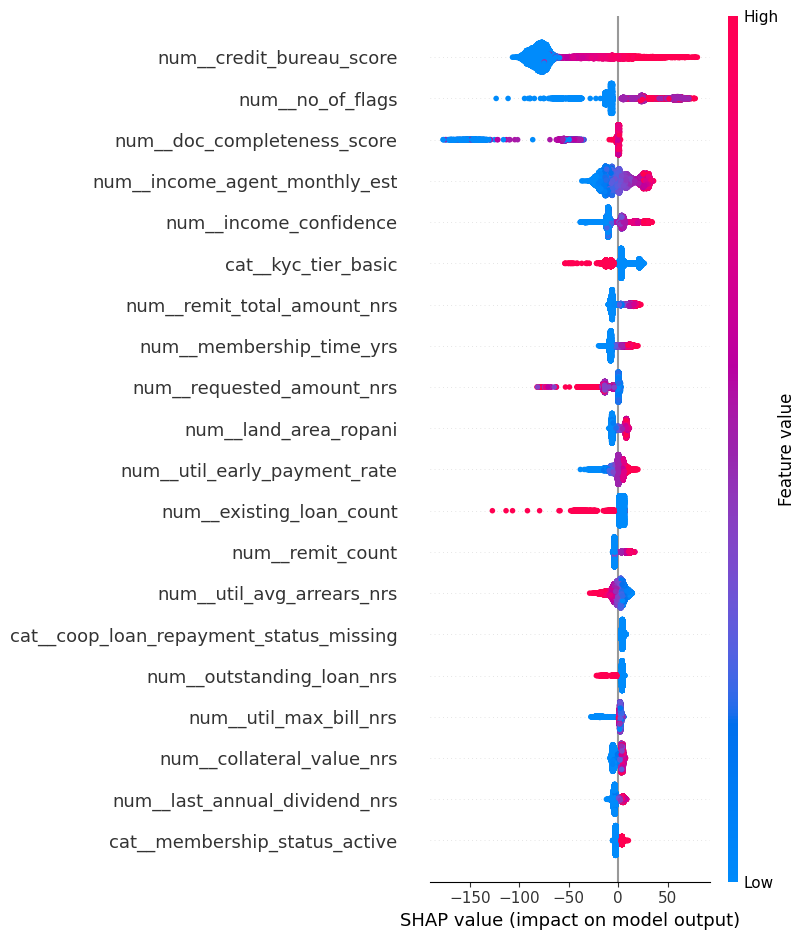

<Figure size 640x480 with 0 Axes>

In [57]:
shap.summary_plot(shap_values, X_test_processed_df, max_display=20)
plt.tight_layout()
plt.show()

### Local Explanations (Force Plot)

Force plots show how individual features push the model's output from the base value (average prediction) to the final predicted value for a specific instance. Red values push the prediction higher, and blue values push it lower.

In [58]:
print("Explaining the first prediction in the test set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_processed_df.iloc[0,:])

Explaining the first prediction in the test set:


In [59]:
print("Explaining a different prediction (e.g., 5th instance) in the test set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[4,:], X_test_processed_df.iloc[4,:])

Explaining a different prediction (e.g., 5th instance) in the test set:


In [61]:
import shap
import joblib
import matplotlib.pyplot as plt
import pandas as pd # Import pandas as it is used for DataFrame creation
import numpy as np

# Assume CATEGORICAL_COLUMNS and X_test are available from previous cells.
# From the kernel state, CATEGORICAL_COLUMNS and X_test are available.

# Get the categorical columns that are actually present in X_test
categorical_cols_in_X_test = [col for col in CATEGORICAL_COLUMNS if col in X_test.columns]

# Then, get the numeric and boolean columns that are in X_test but not in the categorical list
numeric_and_bool_cols = [col for col in X_test.columns if col not in categorical_cols_in_X_test]

# Load the trained pipeline
pipeline = joblib.load('credit_score_model.joblib')

# The pipeline's 'preprocess' step is a ColumnTransformer. We need to get the feature names
# after one-hot encoding for the categorical features.
ohe = pipeline.named_steps['preprocess'].named_transformers_['cat']

# Get feature names after one-hot encoding
# Use 'categorical_cols_in_X_test' to match the columns that were actually processed as categorical
if categorical_cols_in_X_test:
    cat_feature_names = ohe.get_feature_names_out(categorical_cols_in_X_test)
else:
    cat_feature_names = []

# Get the names of the numeric/boolean columns that were passed through
numeric_and_bool_cols_present = numeric_and_bool_cols

# Combine all feature names in the order they appear in the preprocessed data
feature_names_for_shap = list(cat_feature_names) + list(numeric_and_bool_cols_present)

# Get the preprocessed X_test data
X_test_processed = pipeline.named_steps['preprocess'].transform(X_test)

# Ensure X_test_processed is a DataFrame for SHAP, explicitly converting to float
# Explicitly ensure all columns are numeric, coercing any non-numeric to NaN and then filling with 0.
# This is a more robust conversion than .astype(float) if there are hidden non-numeric elements.
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names_for_shap).apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Create human-readable feature names for better interpretability ---

def map_feature_names_to_human_readable(feature_list):
    mapping = {
        'cat__gender_female': 'Gender: Female',
        'cat__gender_male': 'Gender: Male',
        'cat__marital_status_Divorced': 'Marital Status: Divorced',
        'cat__marital_status_Married': 'Marital Status: Married',
        'cat__marital_status_Single': 'Marital Status: Single',
        'cat__marital_status_Widowed': 'Marital Status: Widowed',
        'cat__occupation_en_Artisan': 'Occupation: Artisan',
        'cat__occupation_en_Business Owner': 'Occupation: Business Owner',
        'cat__occupation_en_Daily Wage Worker': 'Occupation: Daily Wage Worker',
        'cat__occupation_en_Driver': 'Occupation: Driver',
        'cat__occupation_en_Farmer': 'Occupation: Farmer',
        'cat__occupation_en_Government Employee': 'Occupation: Government Employee',
        'cat__occupation_en_Nurse/Health Worker': 'Occupation: Nurse/Health Worker',
        'cat__occupation_en_Remittance Dependent': 'Occupation: Remittance Dependent',
        'cat__occupation_en_Service Worker': 'Occupation: Service Worker',
        'cat__occupation_en_Small Trader': 'Occupation: Small Trader',
        'cat__occupation_en_Teacher': 'Occupation: Teacher',
        'cat__education_level_Bachelors': 'Education Level: Bachelors',
        'cat__education_level_Illiterate': 'Education Level: Illiterate',
        'cat__education_level_Intermediate': 'Education Level: Intermediate',
        'cat__education_level_Masters': 'Education Level: Masters',
        'cat__education_level_PhD': 'Education Level: PhD',
        'cat__education_level_Primary': 'Education Level: Primary',
        'cat__education_level_SLC': 'Education Level: SLC',
        'cat__education_level_Unknown': 'Education Level: Unknown',
        'cat__primary_bank_Citizens Bank': 'Primary Bank: Citizens Bank',
        'cat__primary_bank_Everest Bank': 'Primary Bank: Everest Bank',
        'cat__primary_bank_Global IME Bank': 'Primary Bank: Global IME Bank',
        'cat__primary_bank_Himalayan Bank': 'Primary Bank: Himalayan Bank',
        'cat__primary_bank_Kumari Bank': 'Primary Bank: Kumari Bank',
        'cat__primary_bank_Machhapuchhre Bank': 'Primary Bank: Machhapuchhre Bank',
        'cat__primary_bank_NIC Asia Bank': 'Primary Bank: NIC Asia Bank',
        'cat__primary_bank_Nabil Bank': 'Primary Bank: Nabil Bank',
        'cat__primary_bank_Nepal Investment Bank': 'Primary Bank: Nepal Investment Bank',
        'cat__primary_bank_Prime Bank': 'Primary Bank: Prime Bank',
        'cat__primary_bank_Sanima Bank': 'Primary Bank: Sanima Bank',
        'cat__primary_bank_Siddhartha Bank': 'Primary Bank: Siddhartha Bank',
        'cat__kyc_tier_Tier 1': 'KYC Tier: Tier 1',
        'cat__kyc_tier_Tier 2': 'KYC Tier: Tier 2',
        'cat__kyc_tier_Tier 3': 'KYC Tier: Tier 3',
        'cat__rural_urban_rural': 'Rural/Urban: Rural',
        'cat__rural_urban_semi_urban': 'Rural/Urban: Semi-Urban',
        'cat__rural_urban_urban': 'Rural/Urban: Urban',
        'cat__loan_purpose_agricultural_input': 'Loan Purpose: Agricultural Input',
        'cat__loan_purpose_business_expansion': 'Loan Purpose: Business Expansion',
        'cat__loan_purpose_education': 'Loan Purpose: Education',
        'cat__loan_purpose_emergency_medical': 'Loan Purpose: Emergency Medical',
        'cat__loan_purpose_household_expenses': 'Loan Purpose: Household Expenses',
        'cat__loan_purpose_microenterprise_startup': 'Loan Purpose: Microenterprise Startup',
        'cat__loan_purpose_personal_loan': 'Loan Purpose: Personal Loan',
        'cat__loan_purpose_small_trade': 'Loan Purpose: Small Trade',
        'cat__loan_purpose_vehicle_purchase': 'Loan Purpose: Vehicle Purchase',
        'cat__coop_loan_repayment_status_bad_debt': 'Coop Loan Repay Status: Bad Debt',
        'cat__coop_loan_repayment_status_current': 'Coop Loan Repay Status: Current',
        'cat__coop_loan_repayment_status_defaulted': 'Coop Loan Repay Status: Defaulted',
        'cat__coop_loan_repayment_status_late': 'Coop Loan Repay Status: Late',
        'cat__coop_loan_repayment_status_missing': 'Coop Loan Repay Status: Missing',
        'cat__membership_status_active': 'Coop Membership Status: Active',
        'cat__membership_status_dormant': 'Coop Membership Status: Dormant',
        'cat__membership_status_resigned': 'Coop Membership Status: Resigned',
        'cat__cooperative_type_agricultural': 'Cooperative Type: Agricultural',
        'cat__cooperative_type_consumer': 'Cooperative Type: Consumer',
        'cat__cooperative_type_multipurpose': 'Cooperative Type: Multipurpose',
        'cat__cooperative_type_savings_credit': 'Cooperative Type: Savings & Credit',

        'household_size': 'Household Size',
        'land_area_ropani': 'Land Area (Ropani)',
        'remittance_receiving': 'Receives Remittance',
        'cooperative_member': 'Is Cooperative Member',
        'age': 'Age',
        'requested_amount_nrs': 'Requested Loan Amount (NRS)',
        'requested_tenure_months': 'Requested Loan Tenure (Months)',
        'collateral_value_nrs': 'Collateral Value (NRS)',
        'existing_loan_count': 'Existing Loan Count',
        'credit_bureau_score': 'Credit Bureau Score',
        'doc_completeness_score': 'Document Completeness Score',
        'income_agent_monthly_est': 'Estimated Monthly Income',
        'income_confidence': 'Income Confidence Score',
        'has_cib_history': 'Has Credit Bureau History',
        'no_of_flags': 'Number of Compliance Flags',
        'has_wallet': 'Has Digital Wallet',
        'share_count': 'Cooperative Share Count',
        'total_share_value_nrs': 'Total Cooperative Share Value (NRS)',
        'last_annual_dividend_nrs': 'Last Annual Dividend (NRS)',
        'outstanding_loan_nrs': 'Outstanding Cooperative Loan (NRS)',
        'membership_time_yrs': 'Cooperative Membership Time (Years)',
        'num_sales': 'Cooperative Sales Count',
        'total_sales_amount_nrs': 'Total Cooperative Sales Amount (NRS)',
        'last_sale_years_ago': 'Years Since Last Cooperative Sale',
        'has_coop_sales': 'Has Cooperative Sales',
        'remit_total_amount_nrs': 'Remit Total Amount (NRS)',
        'remit_mean_amount_nrs': 'Remit Mean Amount (NRS)',
        'remit_median_amount_nrs': 'Remit Median Amount (NRS)',
        'remit_max_amount_nrs': 'Remit Max Amount (NRS)',
        'remit_count': 'Remit Count',
        'remit_num_unique_countries': 'Remit Unique Countries',
        'remit_min_name_match_score': 'Remit Min Name Match Score',
        'remit_mean_name_match_score': 'Remit Mean Name Match Score',
        'remit_pct_digital': 'Remit % Digital',
        'remit_std_amount_nrs': 'Remit Std Dev Amount (NRS)',
        'remit_income_volatility': 'Remit Income Volatility',
        'remit_monthly_avg_inflow': 'Remit Monthly Avg Inflow (NRS)',
        'has_remittance_history': 'Has Remittance History',
        'wallet_tx_count': 'Wallet Transaction Count',
        'wallet_total_credit': 'Wallet Total Credit',
        'wallet_total_debit': 'Wallet Total Debit',
        'wallet_topup_total': 'Wallet Top-up Total',
        'wallet_p2p_income_total': 'Wallet P2P Income Total',
        'wallet_utility_spend_total': 'Wallet Utility Spend Total',
        'wallet_agri_spend_total': 'Wallet Agri Spend Total',
        'wallet_loan_repay_total': 'Wallet Loan Repay Total',
        'wallet_withdrawal_total': 'Wallet Withdrawal Total',
        'wallet_midnight_tx_count': 'Wallet Midnight Tx Count',
        'wallet_monthly_avg_income': 'Wallet Monthly Avg Income',
        'wallet_monthly_avg_utility': 'Wallet Monthly Avg Utility',
        'wallet_monthly_avg_withdrawal': 'Wallet Monthly Avg Withdrawal',
        'wallet_agri_reinvestment_rate': 'Wallet Agri Reinvestment Rate',
        'wallet_cash_retention_rate': 'Wallet Cash Retention Rate',
        'util_tx_count': 'Utility Tx Count',
        'util_avg_bill_nrs': 'Utility Avg Bill (NRS)',
        'util_max_bill_nrs': 'Utility Max Bill (NRS)',
        'util_max_arrears_nrs': 'Utility Max Arrears (NRS)',
        'util_avg_arrears_nrs': 'Utility Avg Arrears (NRS)',
        'util_avg_days_late': 'Utility Avg Days Late',
        'util_max_days_late': 'Utility Max Days Late',
        'util_late_payment_rate': 'Utility Late Payment Rate',
        'util_early_payment_rate': 'Utility Early Payment Rate',
        'util_severe_late_count': 'Utility Severe Late Count',
        'util_digital_payment_rate': 'Utility Digital Payment Rate',
        'util_arrears_to_bill_ratio': 'Utility Arrears to Bill Ratio',
        'util_bill_std': 'Utility Bill Std Dev',
        'util_bill_volatility': 'Utility Bill Volatility',
        'has_utility_history': 'Has Utility History'
    }
    return [mapping.get(feature, feature) for feature in feature_list]

X_test_processed_df.columns = map_feature_names_to_human_readable(X_test_processed_df.columns)

# Initialize a TreeExplainer for the XGBoost model
explainer = shap.TreeExplainer(pipeline.named_steps['model'])

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed_df)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


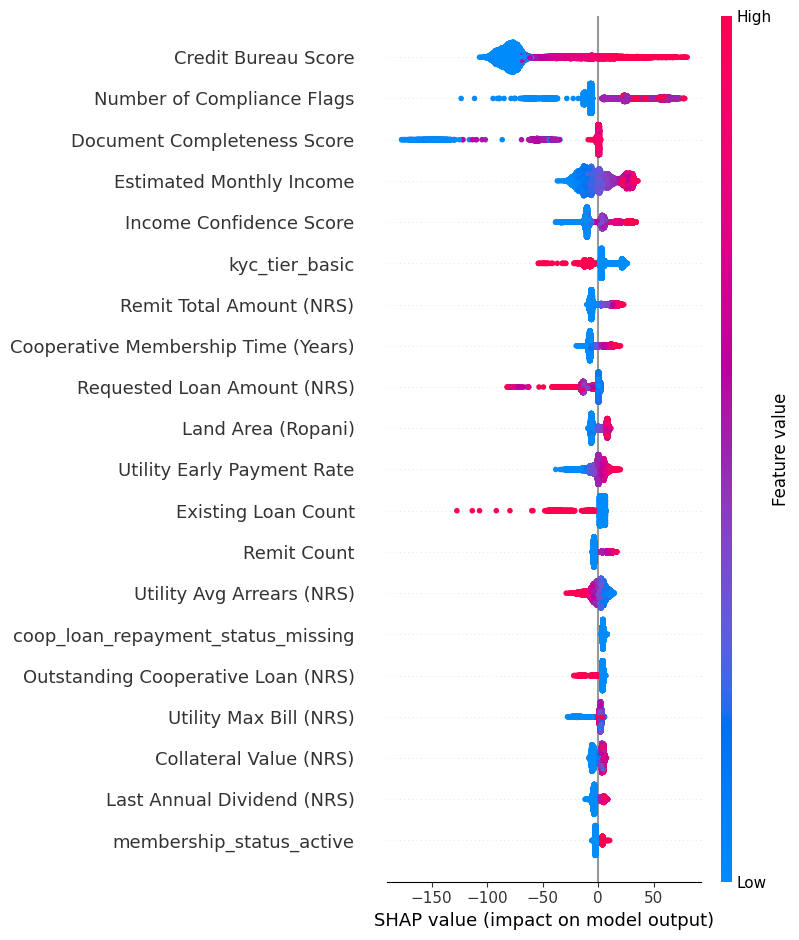

<Figure size 640x480 with 0 Axes>

In [62]:
shap.summary_plot(shap_values, X_test_processed_df, max_display=20)
plt.tight_layout()
plt.show()

### Local Explanations (Force Plot)

Force plots show how individual features push the model's output from the base value (average prediction) to the final predicted value for a specific instance. Red values push the prediction higher, and blue values push it lower.

In [63]:
print("Explaining the first prediction in the test set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_processed_df.iloc[0,:])

Explaining the first prediction in the test set:


In [64]:
print("Explaining a different prediction (e.g., 5th instance) in the test set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[4,:], X_test_processed_df.iloc[4,:])

Explaining a different prediction (e.g., 5th instance) in the test set:


In [66]:
applicant_vector = X_test_processed_df.iloc[[0]]
feature_names = applicant_vector.columns

# Combine features with their SHAP impacts
# Use the pre-calculated SHAP values for this specific instance (assuming `shap_values` is the global one for X_test_processed_df)
impacts = list(zip(feature_names, shap_values[0]))

# Sort by absolute magnitude (biggest impact first)
impacts.sort(key=lambda x: abs(x[1]), reverse=True)

# Generate text for the top 3 drivers
text_explanation = "Credit Decision Explanation:\n"
for feature, impact in impacts[:3]:
    direction = "increased" if impact > 0 else "decreased"
    text_explanation += f"- {feature} {direction} the score by {abs(impact):.2f} points.\n"

print(text_explanation)

Credit Decision Explanation:
- Credit Bureau Score decreased the score by 79.22 points.
- Income Confidence Score decreased the score by 10.39 points.
- Estimated Monthly Income decreased the score by 9.70 points.



In [52]:
shap.summary_plot(shap_values, X_test_processed_df, max_display=20)
plt.tight_layout()
plt.show()

NameError: name 'shap_values' is not defined

In [53]:
print("Explaining the first prediction in the test set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_processed_df.iloc[0,:])

Explaining the first prediction in the test set:


NameError: name 'shap_values' is not defined

In [54]:
print("Explaining a different prediction (e.g., 5th instance) in the test set:")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[4,:], X_test_processed_df.iloc[4,:])

Explaining a different prediction (e.g., 5th instance) in the test set:


NameError: name 'shap_values' is not defined